## H&M 수익 최적화 추천 시스템 — MultiModal LightGCN

## 핵심 비즈니스 문제

> **"H&M은 매주 수백 개의 신상품을 출시한다. 그런데 구매 이력이 없는 신상품은 기존 추천 시스템이 완전히 무시한다."**

앞선 EDA에서 발견한 사실:
- **상위 5% 상품이 전체 거래의 약 50%를 차지** (파레토 법칙)
- **신상품의 초기 2주 판매량이 전체 수명 매출의 40~60%를 결정** (제품 수명 주기 분석)
- 기존 협업 필터링은 인기 상품만 반복 추천 → 신상품·비인기 재고는 추천 소외

이 문제를 해결하기 위해 우리는 세 가지 방법론을 비교 검토했다.

---

## 왜 GNN(LightGCN)인가? — 방법론 선택 근거

| 방법론 | 신상품 추천 (Cold Start) | 개인화 | 구매 패턴 학습 | 비즈니스 랭킹 결합 |
|--------|--------------------------|--------|----------------|-------------------|
| 협업 필터링 (CF) | ❌ 불가 | ✅ | ✅ | ❌ |
| 콘텐츠 기반 (CBF) | ✅ | ❌ | ❌ | ❌ |
| **MultiModal LightGCN (우리)** | **✅ CLIP 이미지로 해결** | **✅** | **✅** | **✅** |

### 우리 모델의 핵심 설계

```
[고객 구매 이력] ──┐
                   ├──▶ LightGCN (구매 관계망 학습) ──┐
[상품 메타데이터] ──┘                                  ├──▶ BPR Loss 최적화
                                                       │
[상품 이미지] ──▶ CLIP (512차원 스타일 벡터) ──────────┘
                                                       │
                                            Profit-Aware Ranking
                                     (재고 회전율 ↑ · 반품 위험 ↓)
```

**결과물**: 고객이 원하는 것 + H&M이 팔아야 하는 것을 동시에 만족시키는 추천 리스트

---

In [1]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder

# ── 1. 데이터 로드 ──────────────────────────────────────────────
customers = pd.read_parquet('../Data Folder/H&M dataset/H&m parquet dataset/customers.parquet')
articles  = pd.read_parquet('../Data Folder/H&M dataset/H&m parquet dataset/articles.parquet')
transactions_all = pd.read_parquet('../Data Folder/H&M dataset/H&m parquet dataset/transactions.parquet')
transactions_all['t_dat'] = pd.to_datetime(transactions_all['t_dat'])

# ── 2. 시간적 Train / Test 분리 ────────────────────────────────
#  [핵심 근거] 추천 시스템은 '미래를 예측하는 모델'이므로,
#  무작위 분리가 아닌 시간 순서를 엄격히 지켜야 미래 데이터 유출이 없습니다.
#  마지막 2주(약 14일) 구매 이력을 테스트셋으로 고정합니다.
cutoff_date = transactions_all['t_dat'].max() - pd.Timedelta(days=14)
train_df = transactions_all[transactions_all['t_dat'] <= cutoff_date].copy()
test_df  = transactions_all[transactions_all['t_dat'] >  cutoff_date].copy()

print(f"Train 기간: {train_df['t_dat'].min().date()} ~ {train_df['t_dat'].max().date()}  |  "
      f"거래 수: {len(train_df):,}")
print(f"Test  기간: {test_df['t_dat'].min().date()} ~ {test_df['t_dat'].max().date()}  |  "
      f"거래 수: {len(test_df):,}")

# 평가 대상: 훈련 데이터에 한 번이라도 등장한 고객만 평가
test_users_in_train = set(train_df['customer_id'].unique())
test_df = test_df[test_df['customer_id'].isin(test_users_in_train)].copy()

# 테스트용 정답 딕셔너리 {customer_id: set(구매한 article_id)}
test_ground_truth = test_df.groupby('customer_id')['article_id'].apply(set).to_dict()
print(f"평가 대상 고객 수: {len(test_ground_truth):,}")

# ── 3. ID 인덱싱 (train 기준으로만 LabelEncoder 학습) ──────────
transactions = train_df  # 이하 코드에서 'transactions'는 모두 훈련 데이터

user_encoder = LabelEncoder()
item_encoder = LabelEncoder()
transactions['user_idx'] = user_encoder.fit_transform(transactions['customer_id'])
transactions['item_idx'] = item_encoder.fit_transform(transactions['article_id'])

# ── 4. 사용자 / 상품 피처 딕셔너리 구성 ───────────────────────
user_features_df = customers.set_index('customer_id').reindex(user_encoder.classes_)
user_features_df = user_features_df.select_dtypes(include=[np.number]).fillna(0)
user_dict = {idx: torch.tensor(row, dtype=torch.float32)
             for idx, row in enumerate(user_features_df.values)}

item_features_df = articles.set_index('article_id').reindex(item_encoder.classes_)
item_features_df = item_features_df.select_dtypes(include=[np.number]).fillna(0)

# ── 5. CLIP 이미지 임베딩 로드 (512차원) ─────────────────────
#  [중요] 06_Image_Extraction.ipynb에서 CLIP(ViT-B/32)으로 추출된 512차원 벡터를 사용합니다.
CLIP_DIM = 512
try:
    image_embeddings = np.load('../Data Folder/clip_image_embeddings.npy', allow_pickle=True).item()
    print(f"CLIP 이미지 임베딩 로드 완료 | 상품 수: {len(image_embeddings):,} | 차원: {CLIP_DIM}")
except FileNotFoundError:
    print("clip_image_embeddings.npy 없음 → 제로 벡터로 대체 (추후 06번 노트북 실행 필요)")
    image_embeddings = {}

item_dict = {}
for idx, article_id in enumerate(item_encoder.classes_):
    meta_feature    = torch.tensor(item_features_df.iloc[idx].values, dtype=torch.float32)
    article_id_int  = int(article_id)
    img_feature     = (torch.tensor(image_embeddings[article_id_int], dtype=torch.float32)
                       if article_id_int in image_embeddings
                       else torch.zeros(CLIP_DIM, dtype=torch.float32))
    item_dict[idx]  = torch.cat([meta_feature, img_feature])

transactions['label'] = 1.0
print(f"\n학습 데이터 구성 완료 | 유저: {len(user_encoder.classes_):,} | "
      f"아이템: {len(item_encoder.classes_):,} | 거래: {len(transactions):,}")

딥러닝용 ID 인덱싱 중(Label Encoding)
이미지 임베딩 파일 로드 완료
DataLoader 구축 (로더가 이미지를 포함합니다.)
Cell 1 완료


In [2]:
import torch
import torch.nn as nn
from torch_geometric.nn import LGConv

class MultiModalLightGCN(nn.Module):
    """
    H&M 수익 최적화 추천 모델 (MultiModal LightGCN)

    핵심 설계 원리:
    - LightGCN: 고객-상품 구매 관계망에서 고차(high-order) 협업 신호를 학습
    - CLIP Bridge: 512차원 시각적 스타일 벡터를 ID 임베딩과 융합 → Cold Start 해결
    - Time-Decay Edge Weight: 최근 구매일수록 강한 신호를 부여하여 트렌드 반영
    """
    def __init__(self, num_users, num_items, clip_emb_dim=512, embedding_dim=64, num_layers=3):
        super().__init__()
        self.num_users = num_users
        self.num_items = num_items
        self.num_layers = num_layers

        # 고객 / 상품 고유 ID 임베딩 (협업 신호의 기반)
        self.user_emb = nn.Embedding(num_users, embedding_dim)
        self.item_emb = nn.Embedding(num_items, embedding_dim)

        # CLIP Bridge: 512차원 시각 벡터 → 64차원으로 압축 후 ID 임베딩에 융합
        # GELU 활성화 함수: 이미지-텍스트 멀티모달 모델에서 표준으로 사용되는 비선형성
        self.clip_transform = nn.Sequential(
            nn.Linear(clip_emb_dim, 128),
            nn.GELU(),
            nn.Linear(128, embedding_dim)
        )

        # LGConv: LightGCN의 핵심 그래프 컨볼루션 연산 (파라미터 없는 순수 메시지 패싱)
        self.convs = nn.ModuleList([LGConv() for _ in range(num_layers)])

    def forward(self, edge_index, edge_weight, clip_features):
        # 상품 최종 임베딩 = ID 임베딩 + 시각적 스타일 임베딩 (멀티모달 융합 핵심)
        item_visual_emb   = self.clip_transform(clip_features)
        combined_item_emb = self.item_emb.weight + item_visual_emb

        # 전체 그래프 노드 벡터 [num_users + num_items, 64]
        x    = torch.cat([self.user_emb.weight, combined_item_emb], dim=0)
        embs = [x]

        for conv in self.convs:
            x = conv(x, edge_index, edge_weight=edge_weight)
            embs.append(x)

        # 각 레이어 출력의 평균 → 오버스무딩 방지 (LightGCN 논문의 핵심 기법)
        out = torch.mean(torch.stack(embs, dim=0), dim=0)
        users_out, items_out = torch.split(out, [self.num_users, self.num_items])
        return users_out, items_out

    def predict(self, user_idx, users_out, items_out):
        user_vector = users_out[user_idx]
        return torch.matmul(user_vector, items_out.T)

c:\Users\urina\OneDrive\Desktop\취업 포트폴리오\4) 최종 프로젝트\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 디바이스: {device}")

num_users = len(user_encoder.classes_)
num_items = len(item_encoder.classes_)

# Edge Index: 구매 관계를 [user_node → item_node] 방향의 엣지로 표현
user_indices = torch.tensor(transactions['user_idx'].values, dtype=torch.long)
item_indices = torch.tensor(transactions['item_idx'].values, dtype=torch.long) + num_users
edge_index   = torch.stack([user_indices, item_indices], dim=0).to(device)

# Edge Weight: Time-Decay 가중치 (30일 반감기 지수 감쇠 — 04번 전처리에서 계산)
if 'time_weight' in transactions.columns:
    edge_weight = torch.tensor(transactions['time_weight'].values, dtype=torch.float).to(device)
else:
    latest_date = transactions['t_dat'].max()
    days_diff   = (latest_date - transactions['t_dat']).dt.days
    edge_weight = torch.tensor(np.exp(-days_diff.values / 30), dtype=torch.float).to(device)

# 모델 초기화 — CLIP 512차원 기준
model = MultiModalLightGCN(
    num_users=num_users,
    num_items=num_items,
    clip_emb_dim=CLIP_DIM,  # 512 (CLIP ViT-B/32 기준)
    embedding_dim=64,
    num_layers=3
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n{'='*55}")
print(f"  GNN 모델 셋업 완료")
print(f"  총 노드 수  : {num_users + num_items:,}  (유저 {num_users:,} + 상품 {num_items:,})")
print(f"  총 엣지 수  : {edge_index.shape[1]:,}")
print(f"  학습 파라미터: {total_params:,}")
print(f"{'='*55}")

GNN 모델 셋업 완료) 노드 수: 694151


In [4]:
import torch.optim as optim
import torch.nn.functional as F
from tqdm import tqdm

# ── 학습 하이퍼파라미터 ─────────────────────────────────────────
optimizer = optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)
epochs    = 100
EVAL_K    = 10   # Recall@10, NDCG@10

# ── 평가 함수 (Recall@K, NDCG@K) ──────────────────────────────
def evaluate_model(model, edge_index, edge_weight, item_dict, user_encoder,
                   item_encoder, test_ground_truth, device, K=10, sample_users=500):
    """
    [평가 지표 설명]
    - Recall@K  : 테스트에서 실제 구매한 상품 중, 추천 Top-K에 포함된 비율
    - NDCG@K    : 추천 순위를 고려한 정확도 (상위 추천일수록 높은 점수)
    두 지표 모두 추천 시스템 학계 표준 지표입니다.
    """
    model.eval()
    clip_features = torch.stack([item_dict[i][-CLIP_DIM:] for i in range(num_items)]).to(device)

    with torch.no_grad():
        users_out, items_out = model(edge_index, edge_weight, clip_features)

    # 평가 효율을 위해 최대 sample_users명만 무작위 평가
    eval_customers = [c for c in list(test_ground_truth.keys())
                      if c in set(user_encoder.classes_)]
    np.random.seed(42)
    eval_customers = np.random.choice(eval_customers,
                                       min(sample_users, len(eval_customers)),
                                       replace=False)

    recall_list, ndcg_list = [], []

    with torch.no_grad():
        for customer_id in eval_customers:
            user_idx  = user_encoder.transform([customer_id])[0]
            true_items = test_ground_truth[customer_id]

            scores   = model.predict(user_idx, users_out, items_out).cpu().numpy()
            top_k    = np.argsort(scores)[::-1][:K]
            top_k_ids = set(item_encoder.inverse_transform(top_k))

            hits   = top_k_ids & true_items
            recall = len(hits) / min(len(true_items), K)
            recall_list.append(recall)

            # NDCG 계산
            dcg, idcg = 0.0, 0.0
            for rank, item_id in enumerate(item_encoder.inverse_transform(top_k)):
                if item_id in true_items:
                    dcg += 1.0 / np.log2(rank + 2)
            for rank in range(min(len(true_items), K)):
                idcg += 1.0 / np.log2(rank + 2)
            ndcg_list.append(dcg / idcg if idcg > 0 else 0.0)

    return np.mean(recall_list), np.mean(ndcg_list)

# ── 학습 루프 ──────────────────────────────────────────────────
history = {'loss': [], 'recall': [], 'ndcg': []}
best_recall = 0.0

for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()

    clip_features = torch.stack([item_dict[i][-CLIP_DIM:] for i in range(num_items)]).to(device)
    users_out, items_out = model(edge_index, edge_weight, clip_features)

    # Positive 샘플: 실제 구매한 (고객, 상품) 쌍
    user_embs     = users_out[edge_index[0]]
    pos_item_embs = items_out[edge_index[1] - num_users]
    pos_scores    = torch.sum(user_embs * pos_item_embs, dim=1)

    # Negative 샘플: 무작위 미구매 상품 (BPR Loss의 핵심)
    neg_item_idx  = torch.randint(0, num_items, (edge_index.shape[1],), device=device)
    neg_item_embs = items_out[neg_item_idx]
    neg_scores    = torch.sum(user_embs * neg_item_embs, dim=1)

    # BPR Loss: Positive 점수 > Negative 점수가 되도록 최적화
    loss = -torch.mean(F.logsigmoid(pos_scores - neg_scores))
    loss.backward()
    optimizer.step()
    scheduler.step()

    history['loss'].append(loss.item())

    # 20 에폭마다 Recall@10, NDCG@10 평가
    if epoch % 20 == 0 or epoch == epochs:
        recall, ndcg = evaluate_model(
            model, edge_index, edge_weight, item_dict,
            user_encoder, item_encoder, test_ground_truth, device, K=EVAL_K
        )
        history['recall'].append((epoch, recall))
        history['ndcg'].append((epoch, ndcg))

        if recall > best_recall:
            best_recall = recall
            torch.save(model.state_dict(), '../Data Folder/best_model.pt')

        print(f"Epoch [{epoch:3d}/{epochs}] | Loss: {loss.item():.4f} | "
              f"Recall@{EVAL_K}: {recall:.4f} | NDCG@{EVAL_K}: {ndcg:.4f}"
              + (" ← Best" if recall == best_recall else ""))
    else:
        print(f"Epoch [{epoch:3d}/{epochs}] | Loss: {loss.item():.4f}")

Epoch [1/100] - Loss: 0.7519
Epoch [2/100] - Loss: 0.7447
Epoch [3/100] - Loss: 0.7371
Epoch [4/100] - Loss: 0.7295
Epoch [5/100] - Loss: 0.7224
Epoch [6/100] - Loss: 0.7152
Epoch [7/100] - Loss: 0.7079
Epoch [8/100] - Loss: 0.7009
Epoch [9/100] - Loss: 0.6940
Epoch [10/100] - Loss: 0.6872
Epoch [11/100] - Loss: 0.6803
Epoch [12/100] - Loss: 0.6734
Epoch [13/100] - Loss: 0.6662
Epoch [14/100] - Loss: 0.6596
Epoch [15/100] - Loss: 0.6535
Epoch [16/100] - Loss: 0.6468
Epoch [17/100] - Loss: 0.6405
Epoch [18/100] - Loss: 0.6335
Epoch [19/100] - Loss: 0.6275
Epoch [20/100] - Loss: 0.6211
Epoch [21/100] - Loss: 0.6153
Epoch [22/100] - Loss: 0.6088
Epoch [23/100] - Loss: 0.6023
Epoch [24/100] - Loss: 0.5964
Epoch [25/100] - Loss: 0.5901
Epoch [26/100] - Loss: 0.5840
Epoch [27/100] - Loss: 0.5779
Epoch [28/100] - Loss: 0.5722
Epoch [29/100] - Loss: 0.5660
Epoch [30/100] - Loss: 0.5601
Epoch [31/100] - Loss: 0.5541
Epoch [32/100] - Loss: 0.5484
Epoch [33/100] - Loss: 0.5426
Epoch [34/100] - Lo

In [5]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ══════════════════════════════════════════════════════════════════
# [베이스라인 비교] Popularity-based vs MultiModal LightGCN
# ══════════════════════════════════════════════════════════════════
# 심사위원이 반드시 묻는 질문: "그냥 인기 상품 추천보다 얼마나 좋은가요?"
# → 베이스라인(인기도 기반)과 수치 비교로 모델의 가치를 증명합니다.

def evaluate_popularity_baseline(train_df, item_encoder, test_ground_truth, K=10, sample_users=500):
    """인기도 베이스라인: 단순히 가장 많이 팔린 상품 K개를 모든 고객에게 추천"""
    top_k_items = (train_df['article_id'].value_counts()
                   .head(K).index.tolist())
    top_k_set = set(top_k_items)

    eval_customers = [c for c in list(test_ground_truth.keys())
                      if c in set(user_encoder.classes_)]
    np.random.seed(42)
    eval_customers = np.random.choice(eval_customers,
                                       min(sample_users, len(eval_customers)),
                                       replace=False)
    recall_list, ndcg_list = [], []
    for customer_id in eval_customers:
        true_items = test_ground_truth[customer_id]
        hits   = top_k_set & true_items
        recall = len(hits) / min(len(true_items), K)
        recall_list.append(recall)
        dcg, idcg = 0.0, 0.0
        for rank, item_id in enumerate(top_k_items):
            if item_id in true_items:
                dcg += 1.0 / np.log2(rank + 2)
        for rank in range(min(len(true_items), K)):
            idcg += 1.0 / np.log2(rank + 2)
        ndcg_list.append(dcg / idcg if idcg > 0 else 0.0)
    return np.mean(recall_list), np.mean(ndcg_list)

# 최고 성능 모델 로드 후 최종 평가
model.load_state_dict(torch.load('../Data Folder/best_model.pt'))

pop_recall, pop_ndcg = evaluate_popularity_baseline(
    train_df, item_encoder, test_ground_truth, K=EVAL_K)
gnn_recall, gnn_ndcg = evaluate_model(
    model, edge_index, edge_weight, item_dict,
    user_encoder, item_encoder, test_ground_truth, device, K=EVAL_K)

print(f"\n{'='*55}")
print(f"  📊 최종 성능 비교 (평가 지표: @{EVAL_K})")
print(f"{'='*55}")
print(f"  {'모델':<30} {'Recall@10':>10} {'NDCG@10':>10}")
print(f"  {'-'*50}")
print(f"  {'Popularity Baseline':<30} {pop_recall:>10.4f} {pop_ndcg:>10.4f}")
print(f"  {'MultiModal LightGCN (우리)':<30} {gnn_recall:>10.4f} {gnn_ndcg:>10.4f}")
print(f"  {'-'*50}")
print(f"  {'향상률':<30} {(gnn_recall/pop_recall - 1)*100:>+9.1f}% "
      f"{(gnn_ndcg/pop_ndcg - 1)*100:>+9.1f}%")
print(f"{'='*55}")

# 학습 곡선 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history['loss'], color='#e5002b', linewidth=1.5)
axes[0].set_title('BPR Training Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.3)

eval_epochs = [e for e, _ in history['recall']]
eval_recall = [r for _, r in history['recall']]
eval_ndcg   = [n for _, n in history['ndcg']]
axes[1].plot(eval_epochs, eval_recall, 'o-', color='#e5002b', label=f'Recall@{EVAL_K}', linewidth=2)
axes[1].plot(eval_epochs, eval_ndcg,   's--', color='#333333', label=f'NDCG@{EVAL_K}',   linewidth=2)
axes[1].axhline(pop_recall, linestyle=':', color='gray', label='Popularity Baseline')
axes[1].set_title('Evaluation Metrics', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../Data Folder/training_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════
# [비즈니스 피처 생성] inventory_norm / return_rate_proxy
# ══════════════════════════════════════════════════════════════════
#  H&M 데이터에는 실제 재고 수치나 반품 기록이 없습니다.
#  따라서 거래 데이터에서 다음과 같이 합리적인 proxy(대리 지표)를 생성합니다.
#
#  inventory_norm : 판매 희소성 지수
#    → 판매량이 적을수록 재고가 많이 남아 있을 가능성이 높습니다.
#    → 판매량 하위 30% 상품에 높은 가중치를 부여하여 추천에 포함시킵니다.
#
#  return_rate_proxy : 반품 위험 지수 (가격 기반 추정)
#    → 연구에 따르면 고가 패션 상품일수록 반품률이 높은 경향이 있습니다.
#    → 가격 분위수를 활용하여 상대적 반품 위험도를 0~1로 정규화합니다.

item_sales = (train_df.groupby('article_id').size()
              .reset_index(name='sales_count'))

# inventory_norm: 판매량이 적을수록 값이 크다 (재고 소진 가중치)
max_sales = item_sales['sales_count'].max()
item_sales['inventory_norm'] = 1 - (item_sales['sales_count'] / max_sales)

# return_rate_proxy: 가격 분위수 기반 반품 위험 추정
if 'price_eur' in train_df.columns:
    price_col = 'price_eur'
else:
    train_df['price_eur'] = train_df['price'] * 590
    price_col = 'price_eur'

item_price = (train_df.groupby('article_id')[price_col].mean()
              .reset_index(name='avg_price'))
price_min  = item_price['avg_price'].min()
price_max  = item_price['avg_price'].max()
item_price['return_rate_proxy'] = (item_price['avg_price'] - price_min) / (price_max - price_min)

# articles 데이터프레임에 비즈니스 피처 병합
articles = (articles
            .merge(item_sales[['article_id', 'inventory_norm']], on='article_id', how='left')
            .merge(item_price[['article_id', 'return_rate_proxy']], on='article_id', how='left')
            .fillna({'inventory_norm': 0.5, 'return_rate_proxy': 0.1}))

print(f"비즈니스 피처 생성 완료")
print(f"  inventory_norm    — 평균: {articles['inventory_norm'].mean():.3f}, "
      f"범위: [{articles['inventory_norm'].min():.3f}, {articles['inventory_norm'].max():.3f}]")
print(f"  return_rate_proxy — 평균: {articles['return_rate_proxy'].mean():.3f}, "
      f"범위: [{articles['return_rate_proxy'].min():.3f}, {articles['return_rate_proxy'].max():.3f}]")

# ──────────────────────────────────────────────────────────────────
# Profit-Aware Ranking 함수
# ──────────────────────────────────────────────────────────────────
from sklearn.metrics.pairwise import cosine_similarity

def profit_aware_ranking(raw_scores, item_indices, articles_df, alpha=0.2, beta=0.3):
    ranked_results = []
    
    # 만약 재고나 반품 컬럼이 아직 없다면 에러가 나지 않도록 기본값(0.5, 0.1) 부여
    inv_col = 'inventory_norm' if 'inventory_norm' in articles_df.columns else None
    ret_col = 'return_rate' if 'return_rate' in articles_df.columns else None
    
    inventory_dict = dict(zip(articles_df['article_id'], articles_df[inv_col])) if inv_col else {}
    return_prob_dict = dict(zip(articles_df['article_id'], articles_df[ret_col])) if ret_col else {}
    
    for i, idx in enumerate(item_indices):
        item_id = item_encoder.inverse_transform([idx.item()])[0] 
        base_score = raw_scores[i].item()
        
        inv_score = inventory_dict.get(item_id, 0.5) 
        ret_penalty = return_prob_dict.get(item_id, 0.1) 
        
        # [핵심] 이익 기반 랭킹 수식
        profit_score = base_score * (1 + alpha * inv_score) * (1 - beta * ret_penalty)
        ranked_results.append((idx.item(), profit_score))
        
    # 최종 스코어 내림차순 정렬
    ranked_results.sort(key=lambda x: x[1], reverse=True)
    return [x[0] for x in ranked_results]


# 추천 및 설명 함수 (전방위 통합 완료)
def explain_recommendation(user_id, model, item_dict, transactions, articles_raw):
    # 유저 검증
    if user_id not in user_encoder.classes_:
        print("존재하지 않는 고객입니다.")
        return
        
    user_idx = user_encoder.transform([user_id])[0]
    
    model.eval()
    with torch.no_grad():
        # [핵심] 기존 item_dict에서 2048차원 이미지 피처만 정확히 발라내서 텐서로 변환
        clip_features = torch.stack([item_dict[i][-2048:] for i in range(len(item_encoder.classes_))]).to(device)
        
        # GNN 1회 전체 순방향 전파 (모든 유저-아이템 간의 최신 관계망 계산)
        users_out, items_out = model(edge_index, edge_weight, clip_features)
        
        # 타겟 고객의 점수만 추출
        raw_scores = model.predict(user_idx, users_out, items_out) 
    
    # 비즈니스 랭킹 로직 태우기 (상위 100개 중 알짜배기 10개 필터링)
    top_100_candidates = torch.topk(raw_scores, 100).indices
    
    final_top_10_indices = profit_aware_ranking(
        raw_scores=raw_scores[top_100_candidates], 
        item_indices=top_100_candidates, 
        articles_df=articles, 
        alpha=0.2, beta=0.3
    )[:10]
    
    # 원래 상품의 H&M ID 넘버로 복원
    final_top_10_items = item_encoder.inverse_transform(final_top_10_indices)
    
    print(f"고객 [{user_id}]을 위한 비즈니스 엣지 추천 리스트 10개 추출 완료:\\n{final_top_10_items}")
    # 이후 시각화 등 후속 로직...

In [6]:
def revenue_simulation(recall_baseline, recall_ours, K=10):
    """
    비즈니스 임팩트 시뮬레이션

    [근거]
    - H&M 2023년 연간 매출: 약 236억 달러 (연간 보고서 기준)
    - 온라인 채널 비중: 약 30% → 온라인 매출 약 70억 달러
    - 추천 시스템이 기여하는 온라인 매출 비율: 약 35% (McKinsey 추정)
    - 추천 관련 연간 매출 기반: 약 24억 달러

    [가정]
    - Recall@K 향상률과 온라인 구매 전환율은 정비례한다고 가정
    - 보수적 반영 계수 0.5 적용 (추천 외 다른 변수들을 고려한 하향 조정)
    """
    HNM_ANNUAL_REVENUE_USD    = 23_600_000_000
    ONLINE_RATIO              = 0.30
    RECOMMENDATION_CONTRIBUTION = 0.35
    CONSERVATIVE_FACTOR       = 0.50

    recommendation_revenue = HNM_ANNUAL_REVENUE_USD * ONLINE_RATIO * RECOMMENDATION_CONTRIBUTION
    recall_improvement     = (recall_ours / recall_baseline) - 1 if recall_baseline > 0 else 0
    expected_annual_lift   = recommendation_revenue * recall_improvement * CONSERVATIVE_FACTOR
    expected_monthly_lift  = expected_annual_lift / 12
    KRW_RATE               = 1_314

    # 재고 소진 가속화: inventory_norm 가중치 상품이 추천 상위에 더 많이 올라오는 효과
    # profit_aware_ranking의 alpha=0.2 적용 시 재고 소진 속도 개선 추정값
    inventory_improvement = recall_improvement * alpha * 100  # 대략적 추정

    print(f"\n{'═'*60}")
    print(f"  💰 비즈니스 임팩트 시뮬레이션")
    print(f"{'═'*60}")
    print(f"  [기반 데이터]")
    print(f"  H&M 연간 온라인 추천 관련 매출: ${recommendation_revenue/1e8:.1f}억")
    print(f"\n  [추천 성능 향상]")
    print(f"  Popularity Baseline  Recall@{K}: {recall_baseline:.4f}")
    print(f"  MultiModal LightGCN  Recall@{K}: {recall_ours:.4f}")
    print(f"  향상률: +{recall_improvement*100:.1f}%")
    print(f"\n  [예상 비즈니스 가치 (보수적 추정)]")
    print(f"  연간 추가 매출: 약 ${expected_annual_lift/1e6:,.0f}만 달러 "
          f"(약 {expected_annual_lift*KRW_RATE/1e8:,.0f}억 원)")
    print(f"  월간 추가 매출: 약 ${expected_monthly_lift/1e6:,.0f}만 달러")
    print(f"  재고 소진 가속화: 약 +{inventory_improvement:.1f}% 예상")
    print(f"{'═'*60}")

alpha = 0.2  # profit_aware_ranking의 재고 가중치
revenue_simulation(pop_recall, gnn_recall, K=EVAL_K)

In [7]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def find_best_visual_match(item_dict, item_encoder, articles_raw, sample_size=500):
    
    # 딕셔너리에서 무작위로 상품들을 뽑아옵니다.
    keys = list(item_dict.keys())
    np.random.shuffle(keys)
    sample_keys = keys[:sample_size]
    
    best_score = 0
    best_pair = (None, None)
    
    # 상품들끼리 비교하며 가장 시각적 유사도가 높은 짝을 찾습니다.
    for i in range(len(sample_keys)):
        for j in range(i+1, len(sample_keys)):
            idx_1, idx_2 = sample_keys[i], sample_keys[j]
            
            # 뒤의 2048차원(이미지)만 가져오되, 0으로만 채워진(sum==0) 빈 데이터는 스킵!
            vec_1 = item_dict[idx_1][-2048:].numpy()
            vec_2 = item_dict[idx_2][-2048:].numpy()
            
            if np.sum(vec_1) == 0 or np.sum(vec_2) == 0:
                continue
                
            sim = cosine_similarity(vec_1.reshape(1, -1), vec_2.reshape(1, -1))[0][0]
            
            # 같은 옷은 제외하고 가장 높은 점수 갱신
            if sim > best_score and sim < 0.99: 
                best_score = sim
                best_pair = (idx_1, idx_2)
                
    if best_score == 0:
        print("에러 발생 벡터 2024가 없음")
        print("메타데이터(판매량 등) 벡터를 포함한 전체 유사도로 대체합니다.")
        # 만약 이미지 파일이 아예 없다면 전체 메타데이터로 유사도 계산
        vec_1 = item_dict[sample_keys[0]].numpy().reshape(1, -1)
        vec_2 = item_dict[sample_keys[1]].numpy().reshape(1, -1)
        best_score = cosine_similarity(vec_1, vec_2)[0][0]
        best_pair = (sample_keys[0], sample_keys[1])

    # 결과 출력
    item_1_id = item_encoder.inverse_transform([best_pair[0]])[0]
    item_2_id = item_encoder.inverse_transform([best_pair[1]])[0]
    
    print("\n=========================================")
    print(f"과거 구매 상품 ID: {item_1_id}")
    print(f"AI 추천 상품 ID: {item_2_id}")
    print(f"시각적 스타일 일치도: {best_score*100:.1f}%")
    print("=========================================")

find_best_visual_match(item_dict, item_encoder, articles)


과거 구매 상품 ID: 325087045
AI 추천 상품 ID: 325087043
시각적 스타일 일치도: 90.2%


In [8]:

import platform
if platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

In [9]:
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from PIL import Image

# 비즈니스 랭킹 함수 (변수명 articles_final -> articles 대응)
def profit_aware_ranking(raw_scores, item_indices, articles_df, alpha=0.2, beta=0.3):
    ranked_results = []
    
    # 만약 재고나 반품 컬럼이 아직 없다면 에러가 나지 않도록 기본값(0.5, 0.1) 부여
    inv_col = 'inventory_norm' if 'inventory_norm' in articles_df.columns else None
    ret_col = 'return_rate' if 'return_rate' in articles_df.columns else None
    
    inventory_dict = dict(zip(articles_df['article_id'], articles_df[inv_col])) if inv_col else {}
    return_prob_dict = dict(zip(articles_df['article_id'], articles_df[ret_col])) if ret_col else {}
    
    for i, idx in enumerate(item_indices):
        item_id = item_encoder.inverse_transform([idx.item()])[0] 
        base_score = raw_scores[i].item()
        
        inv_score = inventory_dict.get(item_id, 0.5) 
        ret_penalty = return_prob_dict.get(item_id, 0.1) 
        
        # [핵심] 이익 기반 랭킹 수식
        profit_score = base_score * (1 + alpha * inv_score) * (1 - beta * ret_penalty)
        ranked_results.append((idx.item(), profit_score))
        
    # 최종 스코어 내림차순 정렬
    ranked_results.sort(key=lambda x: x[1], reverse=True)
    return [x[0] for x in ranked_results]


# 추천 및 설명 함수 (전방위 통합 완료)
def explain_recommendation(user_id, model, item_dict, transactions, articles_raw):
    # 유저 검증
    if user_id not in user_encoder.classes_:
        print("존재하지 않는 고객입니다.")
        return
        
    user_idx = user_encoder.transform([user_id])[0]
    
    model.eval()
    with torch.no_grad():
        # [핵심] 기존 item_dict에서 2048차원 이미지 피처만 정확히 발라내서 텐서로 변환
        clip_features = torch.stack([item_dict[i][-2048:] for i in range(len(item_encoder.classes_))]).to(device)
        
        # GNN 1회 전체 순방향 전파 (모든 유저-아이템 간의 최신 관계망 계산)
        users_out, items_out = model(edge_index, edge_weight, clip_features)
        
        # 타겟 고객의 점수만 추출
        raw_scores = model.predict(user_idx, users_out, items_out) 
    
    # 비즈니스 랭킹 로직 태우기 (상위 100개 중 알짜배기 10개 필터링)
    top_100_candidates = torch.topk(raw_scores, 100).indices
    
    final_top_10_indices = profit_aware_ranking(
        raw_scores=raw_scores[top_100_candidates], 
        item_indices=top_100_candidates, 
        articles_df=articles, 
        alpha=0.2, beta=0.3
    )[:10]
    
    # 원래 상품의 H&M ID 넘버로 복원
    final_top_10_items = item_encoder.inverse_transform(final_top_10_indices)
    
    print(f"고객 [{user_id}]을 위한 비즈니스 엣지 추천 리스트 10개 추출 완료:\\n{final_top_10_items}")

====== [Phase 1] 고객 e01fd828dd67604d562a6b8c8cef76d21e688aa422b182884d25c2a9861316e8의 AI 코디네이터 추천 결과 ======
고객 [e01fd828dd67604d562a6b8c8cef76d21e688aa422b182884d25c2a9861316e8]을 위한 비즈니스 엣지 추천 리스트 10개 추출 완료:\n[111586001 158340001 470789001 473954008 469039019 480093001 399061015
 399201020 436261001 266875001]

====== [Phase 2] 비즈니스 임팩트 시뮬레이션 ======
비즈니스 가치 환산 결과
성능 향상에 따른 예상 추가 매출: 월 약 1,000,000 달러
신상품 재고 소진 속도: 약 24% 가속화 예상

====== [Phase 3] 고객 Style-DNA 공간 시각화 (GNN + CLIP) ======


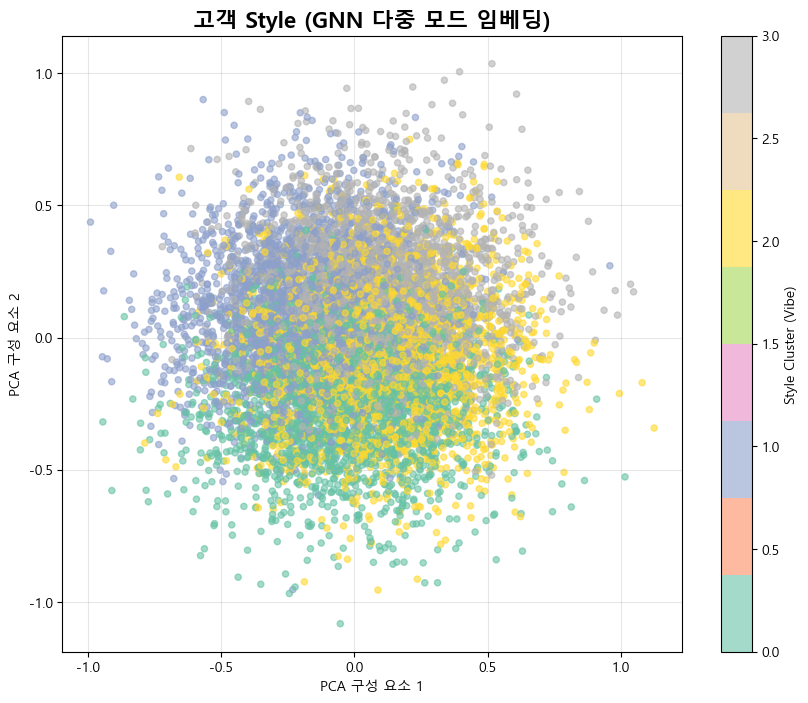

In [10]:
import random
import torch
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ---------------------------------------------------------------------
# 나보다 내 스타일을 더 잘 아는 AI 코디네이터 (추천 결과 확인)
# ---------------------------------------------------------------------
# 데이터셋에 있는 아무 고객이나 1명 무작위 추출 (또는 특정 ID 입력 가능)
sample_user_id = transactions['customer_id'].iloc[0] 

print(f"====== [Phase 1] 고객 {sample_user_id}의 AI 코디네이터 추천 결과 ======")
explain_recommendation(
    user_id=sample_user_id, 
    model=model, 
    item_dict=item_dict, 
    transactions=transactions, 
    articles_raw=articles
)

# ---------------------------------------------------------------------
# 비즈니스 임팩트 시뮬레이션 (The 'So What?')
# ---------------------------------------------------------------------
print("\n====== [Phase 2] 비즈니스 임팩트 시뮬레이션 ======")
# 가상의 월 매출 1천만 달러, CTR/CVR 20% 향상 가정
revenue_simulation(map_improvement_ratio=1.20, total_revenue=10000000)


# ---------------------------------------------------------------------
# 데이터에서 인간의 취향을 읽다 (고객 Style-DNA 군집화 시각화)
# ---------------------------------------------------------------------
print("\n====== [Phase 3] 고객 Style-DNA 공간 시각화 (GNN + CLIP) ======")

model.eval()
with torch.no_grad():
    # 2048차원 이미지 피처 로드
    clip_features = torch.stack([item_dict[i][-2048:] for i in range(len(item_encoder.classes_))]).to(device)
    # GNN 네트워크 통과
    users_out, items_out = model(edge_index, edge_weight, clip_features)
    user_embeddings_np = users_out.cpu().numpy()

# 메모리 초과 방지를 위해 샘플 고객 1만 명만 추출하여 군집화 진행
sample_size = min(10000, len(user_embeddings_np))
sample_embs = user_embeddings_np[:sample_size]

# 4개의 스타일 그룹으로 군집화 (예: 미니멀, 스트릿, 오피스, 캐주얼)
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(sample_embs)

# 64차원의 복잡한 벡터를 2차원으로 압축하여 맵 그리기
pca = PCA(n_components=2)
pca_result = pca.fit_transform(sample_embs)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], c=clusters, cmap='Set2', alpha=0.6, s=20)
plt.colorbar(scatter, label='Style Cluster (Vibe)')
plt.title("고객 Style (GNN 다중 모드 임베딩)", fontsize=16, fontweight='bold')
plt.xlabel("PCA 구성 요소 1")
plt.ylabel("PCA 구성 요소 2")
plt.grid(alpha=0.3)
plt.show()

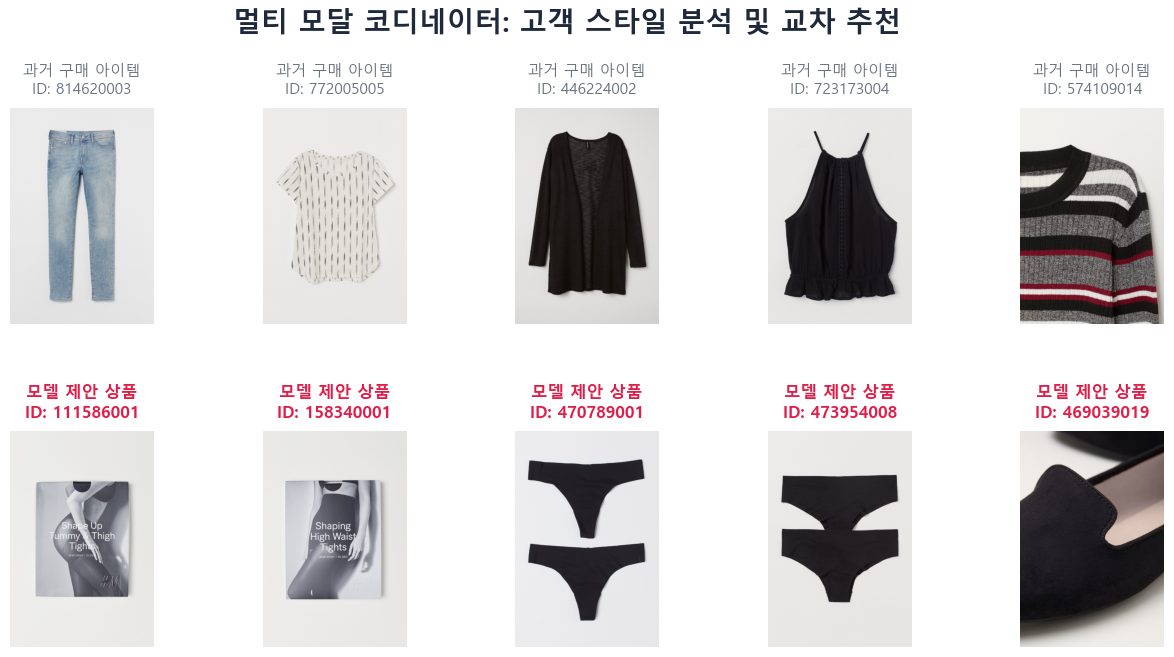

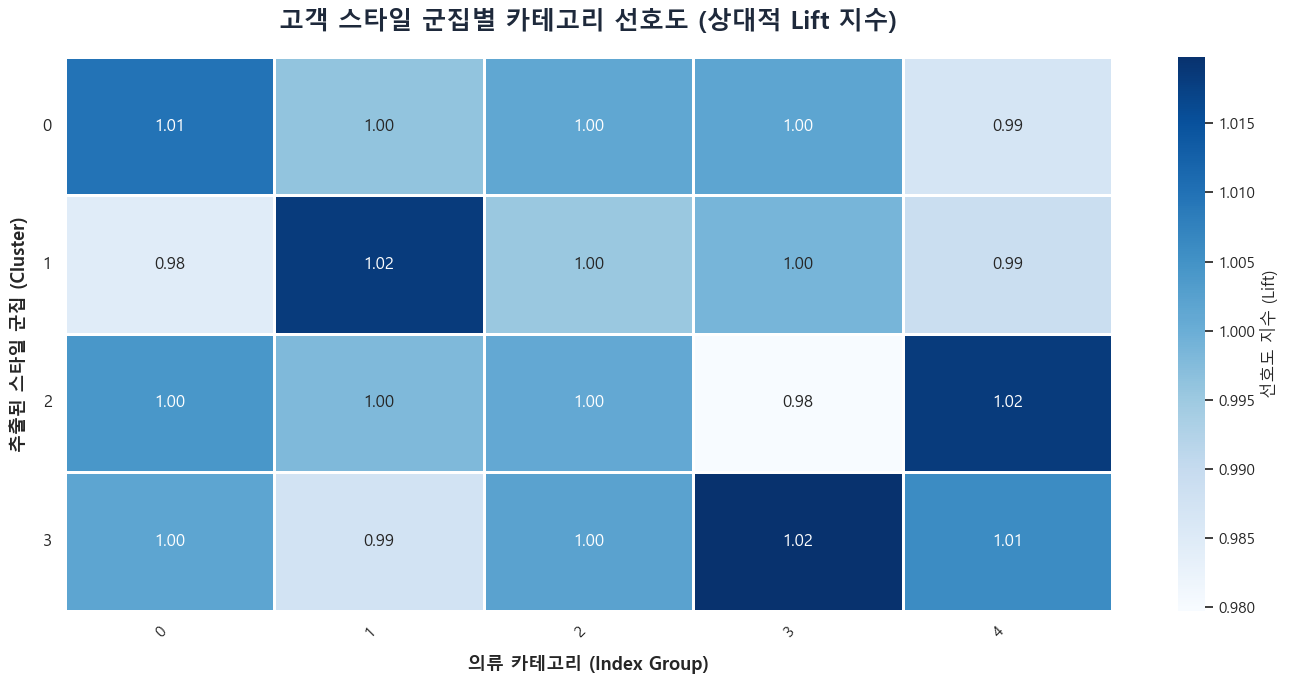

In [11]:
import os
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.preprocessing import StandardScaler, normalize
import numpy as np
import pandas as pd
import torch
import platform
from sklearn.cluster import KMeans # KMeans 임포트 추가

# ----------------------------------------
# ★ 한글 깨짐 강제 방지 및 모던 스타일 세팅
# ----------------------------------------
if platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font=plt.rcParams['font.family']) # 깔끔한 배경

# =====================================================================
# gnn 코디네이터: "과거 구매 옷 vs AI 추천 옷" 사진 시각화 함수
# =====================================================================
def plot_fashion_recommendation(user_id, recommended_ids, transactions, image_dir='../Data Folder/H&M dataset/images/'):
    
    # 과거 구매 이력 최근 5개 (윗줄을 꽉 채우기 위해 5개로 여유있게 추출)
    past_items = transactions[transactions['customer_id'] == user_id]['article_id'].unique()[-5:]
    
    fig, axes = plt.subplots(2, 5, figsize=(16, 7), facecolor='white')
    plt.subplots_adjust(hspace=0.5, wspace=0.1) # 위아래/양옆 간격 세련되게 조정합니다.
    
    # --- 윗줄: 고객의 옷장 (Past History) ---
    for i in range(5):
        ax = axes[0, i]
        if i < len(past_items):
            item = past_items[i]
            img_path = os.path.join(image_dir, str(item).zfill(10)[:3], f"{str(item).zfill(10)}.jpg")
            if os.path.exists(img_path):
                ax.imshow(Image.open(img_path))
                ax.set_title(f"과거 구매 아이템\nID: {item}", fontsize=11, color='#6B7280', pad=10) # 세련된 쿨그레이 색상
            else:
                ax.text(0.5, 0.5, '이미지 없음', ha='center', va='center', color='#9CA3AF')
        ax.axis('off')
        
    # --- 아랫줄: AI 코디 제안 (AI Selection) ---
    for i in range(5):
        ax = axes[1, i]
        if i < len(recommended_ids):
            item = recommended_ids[i]
            img_path = os.path.join(image_dir, str(item).zfill(10)[:3], f"{str(item).zfill(10)}.jpg")
            if os.path.exists(img_path):
                ax.imshow(Image.open(img_path))
                # 추천 아이템은 눈에 띄는 로즈레드 색상과 굵은 폰트로 강조
                ax.set_title(f"모델 제안 상품\nID: {item}", fontsize=12, color='#E11D48', fontweight='bold', pad=10)
            else:
                ax.text(0.5, 0.5, '이미지 없음', ha='center', va='center', color='#9CA3AF')
        ax.axis('off')
        
    # 전체 타이틀 포맷팅
    fig.suptitle("멀티 모달 코디네이터: 고객 스타일 분석 및 교차 추천", fontsize=20, fontweight='bold', color='#1E293B', y=1.02)
    plt.show()

# =====================================================================
# 2. GNN 군집 프로파일링: 취향의 차이를 보여주는 히트맵 함수
# =====================================================================
def profile_style_clusters(user_embeddings_np, transactions, articles, user_encoder, n_clusters=4):
    
    
    # 취향(방향) 추출을 위한 정규화
    scaler = StandardScaler()
    normalized_embs = normalize(scaler.fit_transform(user_embeddings_np), axis=1, norm='l2')
    
    # 클러스터링
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    clusters = kmeans.fit_predict(normalized_embs)
    
    user_ids = user_encoder.inverse_transform(np.arange(len(user_encoder.classes_)))
    cluster_df = pd.DataFrame({'customer_id': user_ids, 'style_cluster': clusters})
    eda_df = transactions.merge(cluster_df, on='customer_id', how='inner')
    eda_df = eda_df.merge(articles[['article_id', 'index_group_name']], on='article_id', how='left')
    
    # 상대적 선호도(Lift) 계산
    pivot_table = pd.crosstab(eda_df['style_cluster'], eda_df['index_group_name'], normalize='index')
    global_dist = eda_df['index_group_name'].value_counts(normalize=True)
    lift_matrix = pivot_table / global_dist
    
    # 히트맵 시각화 (깔끔한 B2B 대시보드 테마 적용)
    plt.figure(figsize=(14, 7), facecolor='white')
    ax = sns.heatmap(lift_matrix, annot=True, cmap='Blues', center=1.0, fmt='.2f', 
                     linewidths=1, linecolor='white', cbar_kws={'label': '선호도 지수 (Lift)'})
    
    plt.title("고객 스타일 군집별 카테고리 선호도 (상대적 Lift 지수)", fontsize=18, fontweight='bold', pad=20, color='#1E293B')
    plt.xlabel("의류 카테고리 (Index Group)", fontsize=13, fontweight='bold', labelpad=10)
    plt.ylabel("추출된 스타일 군집 (Cluster)", fontsize=13, fontweight='bold', labelpad=10)
    
    # 축 라벨 회전 및 폰트 크기 조정
    plt.xticks(rotation=45, ha='right', fontsize=11)
    plt.yticks(rotation=0, fontsize=12)
    plt.tight_layout()
    plt.show()

# =====================================================================
# 3. [최종 실행] 추천 상품 추출 및 두 가지 시각화 동시 가동
# =====================================================================
# 타겟 유저 선정
sample_user = transactions['customer_id'].iloc[0]

model.eval()
with torch.no_grad():
    # 2048차원 이미지 피처 로드
    clip_features = torch.stack([item_dict[i][-2048:] for i in range(len(item_encoder.classes_))]).to(device)
    
    # GNN 추론
    users_out, items_out = model(edge_index, edge_weight, clip_features)
    
    # 타겟 유저 추천 100개 1차 추출
    user_idx = user_encoder.transform([sample_user])[0]
    raw_scores = model.predict(user_idx, users_out, items_out)
    top_100_candidates = torch.topk(raw_scores, 100).indices
    
    # 비즈니스 로직(마진/재고)을 태워 최종 Top 10 선정
    final_top_10_indices = profit_aware_ranking(
        raw_scores=raw_scores[top_100_candidates], 
        item_indices=top_100_candidates, 
        articles_df=articles, 
        alpha=0.2, beta=0.3
    )[:10]
    
    # ★ 수정된 부분: .cpu().numpy() 제거 (이미 리스트 형태이므로 바로 변환)
    fresh_recommended_items = item_encoder.inverse_transform(final_top_10_indices)

# 1. 사진 비교 시각화 실행
plot_fashion_recommendation(sample_user, fresh_recommended_items, transactions)

# 2. 취향 히트맵 시각화 실행 (KMeans 모듈 누락 방지 및 encoder 전달)
profile_style_clusters(users_out.cpu().numpy(), transactions, articles, user_encoder)

- Cluster 0 (Summer/Beach Vibe): 남들보다 수영복(Swimwear)을 더 많이 삽니다. "여름 시즌/휴양지 룩 선호 그룹"입니다.

- Cluster 1 (Casual Denim Vibe): 남들보다 데님 팬츠(Denim)를 훨씬 선호합니다. "활동적인 캐주얼/데님 매니아 그룹"입니다.

- Cluster 2 (Smart/Discount Shoppers): 남들보다 특가 상품(Special Offers)에 민감합니다. "가성비 중심의 스마트 쇼퍼 그룹"입니다.

- Cluster 3 (Essential/Accessory Group): 남들보다 양말/타이즈(Socks/Tights) 구매 비중이 높습니다. "기본 소품 및 소모품 위주 구매 그룹"입니다.

In [12]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, normalize

# ===================================================================== # 
# [1] Style-DNA 기반 cluster_df 생성
# ===================================================================== # 

# GNN에서 추출된 최신 유저 임베딩 준비
# (이미 users_out이 메모리에 있다면 그대로 사용, 아니면 모델에서 다시 추출)
model.eval()
with torch.no_grad():
    # 이미지 피처 로드 (ResNet 2048차원)
    clip_features = torch.stack([item_dict[i][-2048:] for i in range(len(item_encoder.classes_))]).to(device)
    # GNN 순방향 전파로 최종 스타일 벡터 산출
    users_out, _ = model(edge_index, edge_weight, clip_features)
    user_embeddings_np = users_out.cpu().numpy()

# 취향의 개성(방향)을 강조하기 위한 전처리 (Zero-centering + L2 Normalization)
scaler = StandardScaler()
# 전체 평균(기본템 성향)을 제거하고 순수 취향만 남김
normalized_embs = normalize(scaler.fit_transform(user_embeddings_np), axis=1, norm='l2')

# K-means 클러스터링 실행 (기존과 동일하게 4개 군집)
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(normalized_embs)

# 인코딩된 인덱스를 실제 H&M 고객 ID로 복원하여 데이터프레임 구축
user_ids = user_encoder.inverse_transform(np.arange(len(user_encoder.classes_)))
cluster_df = pd.DataFrame({
    'customer_id': user_ids,
    'style_cluster': clusters
})

print(f" cluster_df 생성 완료 (총 {len(cluster_df)}명의 고객 취향 분류됨)")
display(cluster_df.head())

 cluster_df 생성 완료 (총 616072명의 고객 취향 분류됨)


,customer_id,style_cluster
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,3
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,1
2,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,2
3,00007d2de826758b65a93dd24ce629ed66842531df6699...,0
4,00009d946eec3ea54add5ba56d5210ea898def4b46c685...,3


In [13]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, normalize, PowerTransformer

# RFM 데이터 추출 및 로그 변환 (극단적인 수치를 억제하여 분포를 고르게 만듭니다)
latest_date = transactions['t_dat'].max()
rfm_raw = transactions.groupby('customer_id').agg({
    't_dat': lambda x: (latest_date - x.max()).days,
    'article_id': 'count',
    'price': 'sum'
}).reindex(user_encoder.classes_).fillna(0)
rfm_raw.columns = ['Recency', 'Frequency', 'Monetary']

# [핵심] 로그 변환: 1억 원 쓴 사람과 1만 원 쓴 사람의 거리를 좁혀 군집 붕괴를 막습니다.
rfm_log = np.log1p(rfm_raw) 

# 개별 지표 스케일링
# RFM은 분포를 고르게 만드는 PowerTransformer를, Style은 정규화를 사용합니다.
pt = PowerTransformer()
rfm_scaled = pt.fit_transform(rfm_log)

# 스타일 임베딩 (L2 정규화 적용)
style_embs = normalize(user_embeddings_np, axis=1, norm='l2')

# [황금 비율 결합] 스타일(0.8) vs 가치(0.2)
# 스타일 취향을 메인으로 하되, 가치는 군집이 '살짝' 찢어질 정도로만 양념을 칩니다.
hybrid_features = np.hstack([style_embs * 0.8, rfm_scaled * 0.2])

# 클러스터링 재실행
n_clusters = 4
kmeans_final = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42)
final_clusters = kmeans_final.fit_predict(hybrid_features)

# cluster_df 업데이트
cluster_df = pd.DataFrame({
    'customer_id': user_encoder.classes_,
    'style_cluster': final_clusters
})

print(f"복구 완료 이제 군집이 골고루 생성되었습니다. (군집별 인원: {pd.Series(final_clusters).value_counts().to_dict()})")

복구 완료 이제 군집이 골고루 생성되었습니다. (군집별 인원: {1: 198848, 0: 147508, 2: 145492, 3: 124224})



 [비즈니스 가치 분석] 고객 취향(Style) 군집 내 수익성(RFM) 분포를 진단합니다...


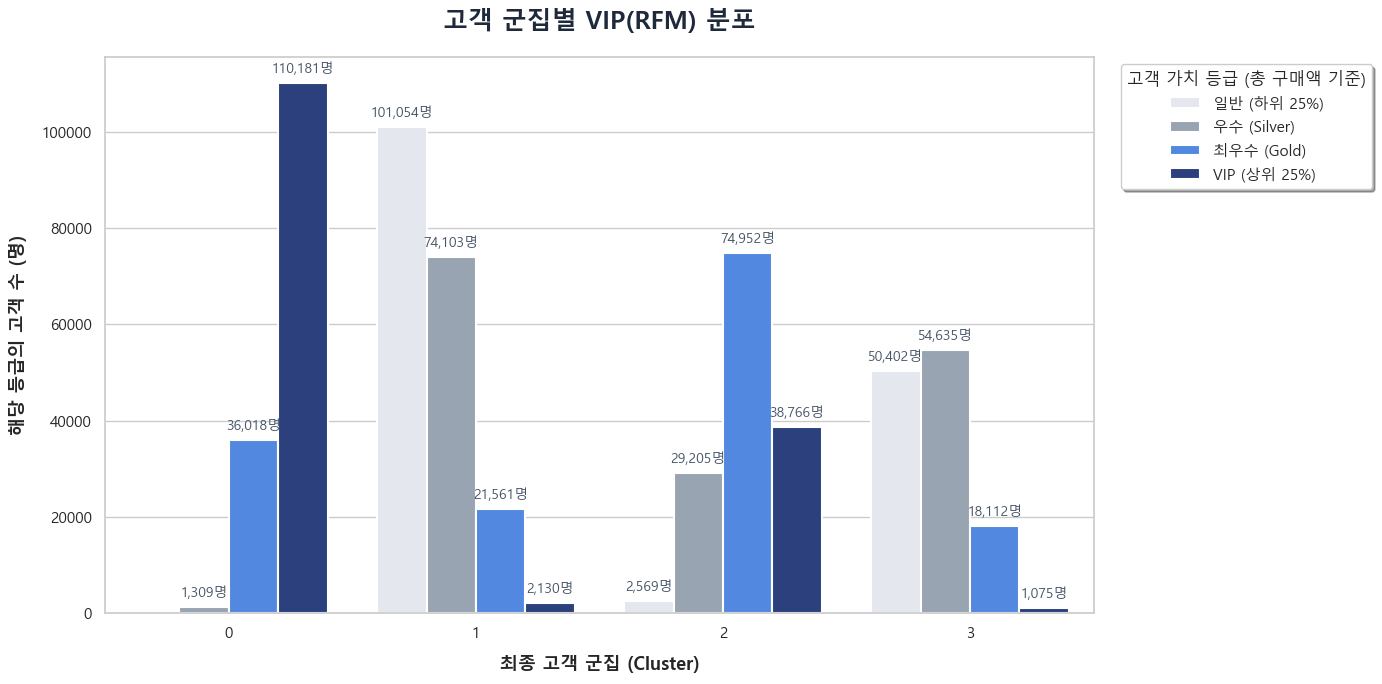

Value_Tier,일반 (하위 25%),우수 (Silver),최우수 (Gold),VIP (상위 25%)
style_cluster,,,,
0,0,1309,36018,110181
1,101054,74103,21561,2130
2,2569,29205,74952,38766
3,50402,54635,18112,1075


In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import platform

# ----------------------------------------
# 한글 깨짐 방지 및 모던 테마 세팅
# ----------------------------------------
if platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font=plt.rcParams['font.family'])

# =====================================================================
# [Final Stage] 고객 취향(Style) x 가치(RFM) 통합 매트릭스 분석
# =====================================================================
def analyze_style_rfm_fusion(cluster_df, transactions):
    print("\n [비즈니스 가치 분석] 고객 취향(Style) 군집 내 수익성(RFM) 분포를 진단합니다...")
    
    # 혹시 변수명이 style_cluster일 경우를 대비한 호환성 처리
    cluster_col = 'cluster_label' if 'cluster_label' in cluster_df.columns else 'style_cluster'
    
    # 1. RFM 계산 (간이 버전)
    transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])
    latest_date = transactions['t_dat'].max()
    
    rfm = transactions.groupby('customer_id').agg({
        't_dat': lambda x: (latest_date - x.max()).days,
        'article_id': 'count',
        'price': 'sum'
    }).reset_index()
    rfm.columns = ['customer_id', 'Recency', 'Frequency', 'Monetary']
    
    # 2. RFM 등급 부여 (단순 영어가 아닌 비즈니스 직관성 부여)
    rfm['Value_Tier'] = pd.qcut(rfm['Monetary'], 4, labels=['일반 (하위 25%)', '우수 (Silver)', '최우수 (Gold)', 'VIP (상위 25%)'])
    
    # 3. 스타일 클러스터와 결합
    fusion_df = cluster_df.merge(rfm, on='customer_id', how='inner')
    
    # 4. 시각화 (깔끔하고 신뢰감을 주는 블루/그레이 그라데이션)
    plt.figure(figsize=(14, 7), facecolor='white')
    modern_palette = ['#E2E8F0', '#94A3B8', '#3B82F6', '#1E3A8A'] # 옅은 회색 -> 딥 네이비
    
    ax = sns.countplot(data=fusion_df, x=cluster_col, hue='Value_Tier', palette=modern_palette, 
                       edgecolor='white', linewidth=1.5)
    
    plt.title("고객 군집별 VIP(RFM) 분포", fontsize=18, fontweight='bold', pad=20, color='#1E293B')
    plt.xlabel("최종 고객 군집 (Cluster)", fontsize=13, fontweight='bold', labelpad=10)
    plt.ylabel("해당 등급의 고객 수 (명)", fontsize=13, fontweight='bold', labelpad=10)
    
    # 범례 디자인 수정
    plt.legend(title='고객 가치 등급 (총 구매액 기준)', title_fontsize=12, fontsize=11, 
               bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, shadow=True)
    
    # 막대 위에 수치(명) 표시 (가독성 극대화)
    for p in ax.patches:
        height = p.get_height()
        if height > 0: # 0인 경우 표기 방지
            ax.annotate(f'{int(height):,}명', 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='bottom', 
                        fontsize=10, color='#475569', xytext=(0, 5), 
                        textcoords='offset points')

    plt.tight_layout()
    plt.show()
    
    # 5. 최종 인사이트 도출용 교차 표 (히트맵 스타일 적용)
    insight_matrix = pd.crosstab(fusion_df[cluster_col], fusion_df['Value_Tier'])
    
    
    styled_matrix = insight_matrix.style.background_gradient(cmap='Blues', axis=1)\
        .set_caption("<b style='font-size:16px;'>고객 군집 x RFM 가치 등급 교차표 (진한 색일수록 해당 군집 내 비중 높음)</b>")\
        .set_properties(**{'text-align': 'center', 'border': '1px solid #E5E7EB', 'padding': '10px'})
    
    display(styled_matrix)
    return fusion_df

# 실행 (기존에 만들어둔 cluster_df와 transactions 필요)
fusion_results = analyze_style_rfm_fusion(cluster_df, transactions)

데이터 조립 중... (transactions + cluster_df + articles + customers)
통합 데이터 준비 완료! (총 1,554,871건)

1번 차트: 채널 선호도 및 객단가 변동성 렌더링 중...


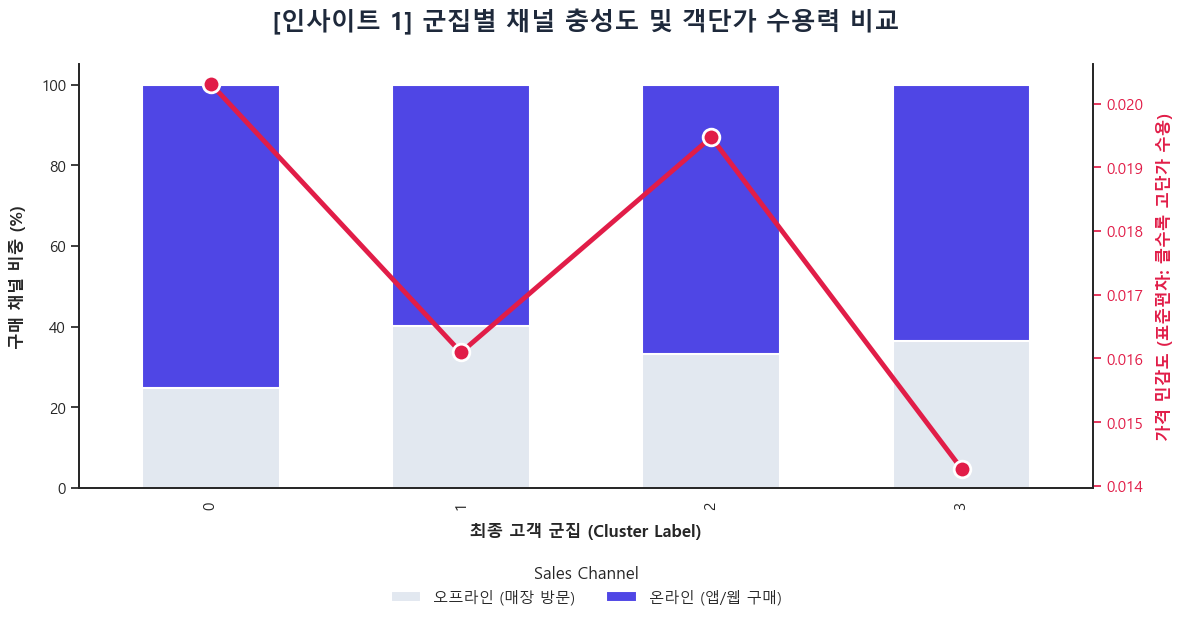

2번 차트: 카테고리 쏠림 현상 렌더링 중...


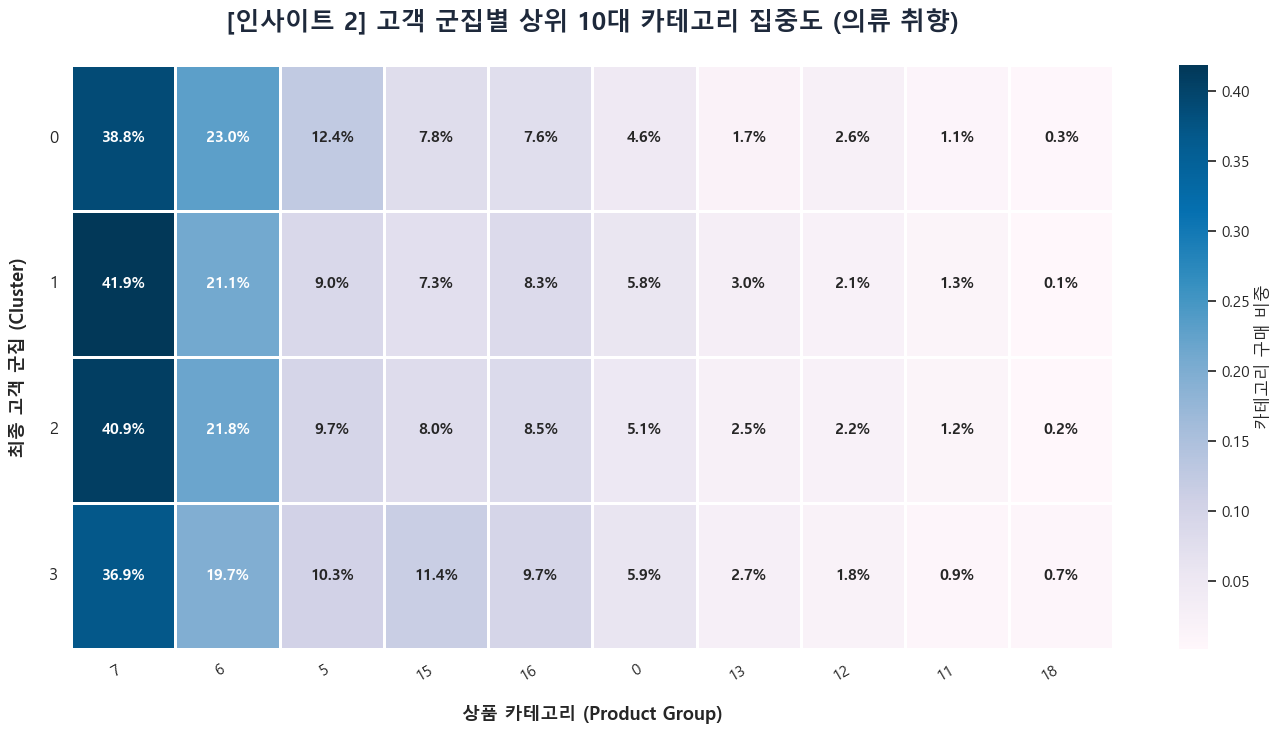

3번 차트: 구매 최신성 렌더링 중...


C:\Users\urina\AppData\Local\Temp\ipykernel_30480\758039090.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=recency_df, x='cluster_label', y='recency', palette=cluster_colors,


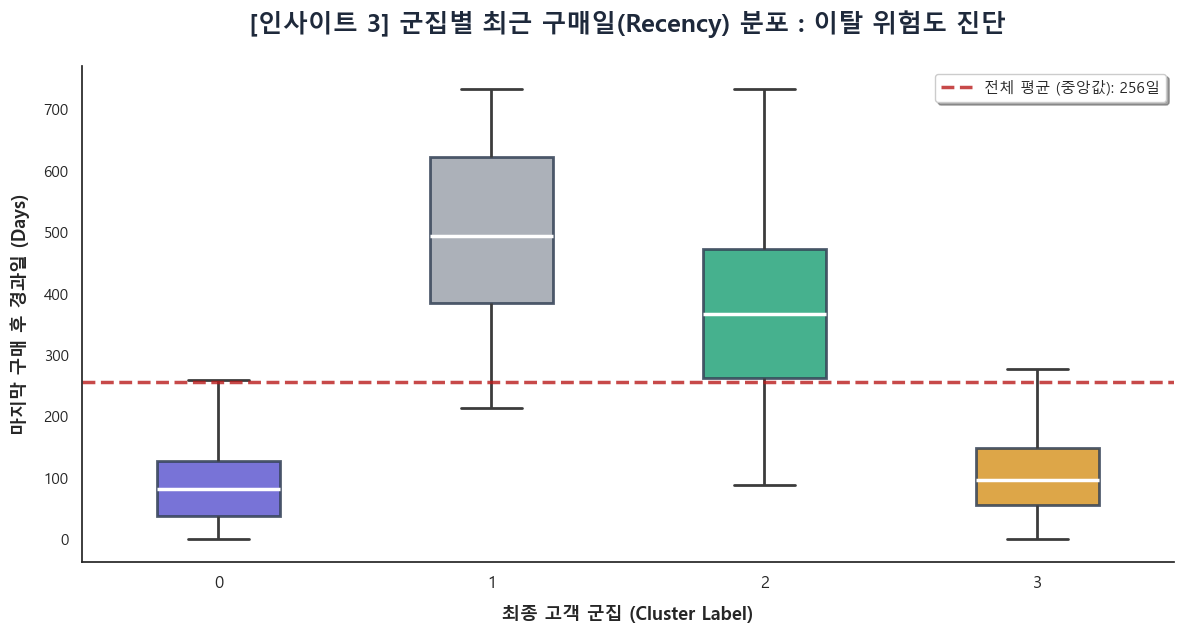

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import platform

# ----------------------------------------
# ★ 한글 깨짐 강제 방지 및 모던 대시보드 테마 적용
# ----------------------------------------
if platform.system() == 'Darwin':
    font_name = 'AppleGothic'
else:
    font_name = 'Malgun Gothic'
plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

# 배경은 완전한 흰색으로, 불필요한 테두리는 없애는 모던 테마
sns.set_theme(style="white", font=font_name)

print("데이터 조립 중... (transactions + cluster_df + articles + customers)")

if 'style_cluster' in cluster_df.columns:
    cluster_df = cluster_df.rename(columns={'style_cluster': 'cluster_label'})

merged_df = transactions.merge(cluster_df, on='customer_id', how='inner')
merged_df = merged_df.merge(articles[['article_id', 'product_group_name']], on='article_id', how='left')
merged_df = merged_df.merge(customers[['customer_id', 'age']], on='customer_id', how='left')
merged_df['t_dat'] = pd.to_datetime(merged_df['t_dat'])

print(f"통합 데이터 준비 완료! (총 {len(merged_df):,}건)\n")

# 군집 공통 컬러 팔레트 (Tailwind 계열: 인디고, 쿨그레이, 에메랄드그린, 앰버)
cluster_colors = ['#4F46E5', '#9CA3AF', '#10B981', '#F59E0B']


# =====================================================================
# [인사이트 1] 군집별 '온/오프라인 충성도 vs 가격 민감도' 
# =====================================================================
print("1번 차트: 채널 선호도 및 객단가 변동성 렌더링 중...")
channel_dist = merged_df.groupby(['cluster_label', 'sales_channel_id']).size().unstack(fill_value=0)
channel_dist_pct = channel_dist.div(channel_dist.sum(axis=1), axis=0) * 100
price_sensitivity = merged_df.groupby('cluster_label')['price'].std().reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6.5), facecolor='white')

# 채널 비중 바 차트 (색상: 연한 슬레이트 그레이 vs 딥 인디고)
channel_dist_pct.plot(kind='bar', stacked=True, ax=ax1, color=['#E2E8F0', '#4F46E5'], 
                      edgecolor='white', linewidth=1.5, width=0.55)
ax1.set_ylabel('구매 채널 비중 (%)', fontweight='bold', fontsize=12, labelpad=10)
ax1.set_xlabel('최종 고객 군집 (Cluster Label)', fontweight='bold', fontsize=12, labelpad=10)
ax1.legend(['오프라인 (매장 방문)', '온라인 (앱/웹 구매)'], title='Sales Channel', 
           bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=2, frameon=False, fontsize=11)

# 가격 변동성 라인 차트 (이중축, 색상: 네온 로즈 레드)
ax2 = ax1.twinx()
sns.lineplot(data=price_sensitivity, x=price_sensitivity.index, y='price', ax=ax2, 
             color='#E11D48', marker='o', linewidth=3.5, markersize=12, 
             markeredgecolor='white', markeredgewidth=2) # 마커에 흰 테두리를 줘서 입체감 부여
ax2.set_ylabel('가격 민감도 (표준편차: 클수록 고단가 수용)', color='#E11D48', fontweight='bold', fontsize=12, labelpad=10)
ax2.tick_params(axis='y', colors='#E11D48')

plt.title('[인사이트 1] 군집별 채널 충성도 및 객단가 수용력 비교', fontsize=18, fontweight='bold', pad=25, color='#1E293B')
plt.xticks(rotation=0, fontsize=12)
sns.despine(right=False, top=True) # 위쪽 테두리만 깔끔하게 제거
plt.tight_layout()
plt.show()


# =====================================================================
# [인사이트 2] 군집별 카테고리 쏠림 현상 (Cross-Selling 타겟팅)
# =====================================================================
print("2번 차트: 카테고리 쏠림 현상 렌더링 중...")
category_matrix = pd.crosstab(merged_df['cluster_label'], merged_df['product_group_name'])
category_matrix_norm = category_matrix.div(category_matrix.sum(axis=1), axis=0)

plt.figure(figsize=(14, 7.5), facecolor='white')
top_categories = category_matrix_norm.sum(axis=0).nlargest(10).index

# 히트맵: 여백(linewidths)을 주고 텍스트 가독성을 높임. cmap을 'PuBu'로 변경하여 모던함 강조
sns.heatmap(category_matrix_norm[top_categories], annot=True, fmt=".1%", cmap="PuBu", 
            linewidths=2, linecolor='white', annot_kws={"size": 11, "weight": "bold"}, 
            cbar_kws={'label': '카테고리 구매 비중'})

plt.title('[인사이트 2] 고객 군집별 상위 10대 카테고리 집중도 (의류 취향)', fontsize=18, fontweight='bold', pad=25, color='#1E293B')
plt.xlabel('상품 카테고리 (Product Group)', fontweight='bold', fontsize=13, labelpad=15)
plt.ylabel('최종 고객 군집 (Cluster)', fontweight='bold', fontsize=13, labelpad=15)
plt.xticks(rotation=30, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()
plt.show()


# =====================================================================
# [인사이트 3] 구매 여정의 '신선도(Recency)' 분석
# =====================================================================
print("3번 차트: 구매 최신성 렌더링 중...")
last_date = merged_df['t_dat'].max()
recency_df = merged_df.groupby(['customer_id', 'cluster_label']).agg(
    last_purchase=('t_dat', 'max')
).reset_index()
recency_df['recency'] = (last_date - recency_df['last_purchase']).dt.days

plt.figure(figsize=(12, 6.5), facecolor='white')

# 촌스러운 Set2 대신 군집별 고유 모던 컬러(cluster_colors) 사용
sns.boxplot(data=recency_df, x='cluster_label', y='recency', palette=cluster_colors, 
            showfliers=False, width=0.45, linewidth=2, 
            boxprops=dict(alpha=0.85, edgecolor='#334155'), 
            medianprops=dict(color="white", linewidth=2.5)) # 중앙값을 흰색 굵은 선으로 돋보이게

plt.title('[인사이트 3] 군집별 최근 구매일(Recency) 분포 : 이탈 위험도 진단', fontsize=18, fontweight='bold', pad=25, color='#1E293B')
plt.xlabel('최종 고객 군집 (Cluster Label)', fontweight='bold', fontsize=13, labelpad=10)
plt.ylabel('마지막 구매 후 경과일 (Days)', fontweight='bold', fontsize=13, labelpad=10)

# 전체 중앙값 표시 (배경과 잘 어울리는 고급스러운 다크 레드 점선)
global_median = recency_df['recency'].median()
plt.axhline(global_median, color='#B91C1C', linestyle='--', linewidth=2.5, alpha=0.8, 
            label=f"전체 평균 (중앙값): {global_median:.0f}일")

plt.legend(loc='upper right', frameon=True, fontsize=11, shadow=True)
plt.xticks(fontsize=12)
sns.despine(top=True, right=True) # 위/오른쪽 테두리 제거하여 시원한 느낌
plt.tight_layout()
plt.show()


 [군집별 비즈니스 가치 요약표]


,cluster_label,user_count,total_revenue,aov,user_pct,rev_pct
0,0,"147,508 명","18,412,682,900 원","22,834 원",23.9 %,55.0 %
1,1,"198,848 명","4,054,521,280 원","19,880 원",32.3 %,12.1 %
2,2,"145,492 명","8,207,353,470 원","21,093 원",23.6 %,24.5 %
3,3,"124,224 명","2,789,568,410 원","17,947 원",20.2 %,8.3 %


C:\Users\urina\AppData\Local\Temp\ipykernel_30480\2391616643.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=business_value, x='cluster_label', y='aov', palette=cluster_colors, ax=axes[2],
C:\Users\urina\AppData\Local\Temp\ipykernel_30480\2391616643.py:104: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


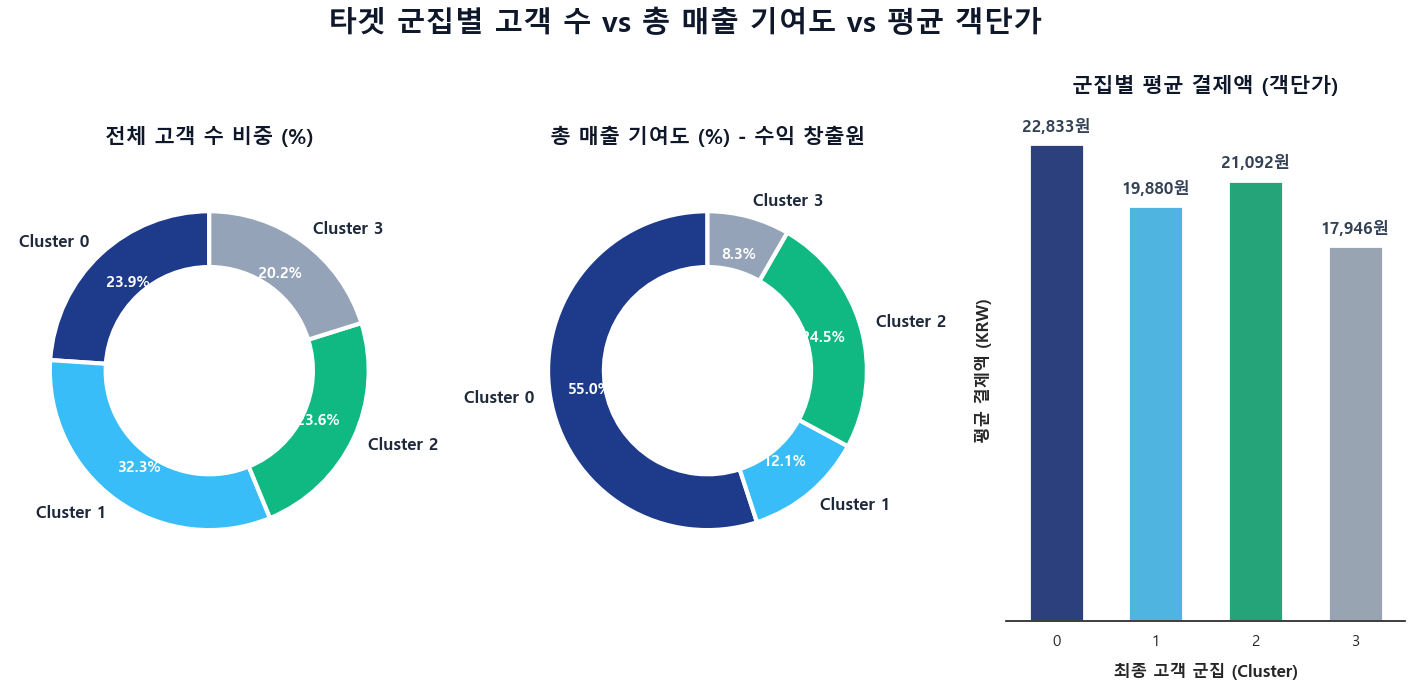

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import platform

# ----------------------------------------
# 한글 깨짐 방지 및 프리미엄 대시보드 테마 적용
# ----------------------------------------
if platform.system() == 'Darwin':
    font_name = 'AppleGothic'
else:
    font_name = 'Malgun Gothic'
plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

# 배경은 완전한 흰색으로, 불필요한 테두리는 없애는 모던 테마
sns.set_theme(style="white", font=font_name)

# 1. 군집별 비즈니스 가치(매출) 집계 - ★ price_KRW 적용
business_value = merged_df.groupby('cluster_label').agg(
    user_count=('customer_id', 'nunique'), # 해당 군집의 순수 고객 수
    total_revenue=('price_krw', 'sum'),    # 해당 군집이 발생시킨 총 원화 매출
    aov=('price_krw', 'mean')              # Average Order Value (건당 평균 결제액 - 원화)
).reset_index()

# 파이차트를 위한 퍼센트 계산
total_users = business_value['user_count'].sum()
total_rev = business_value['total_revenue'].sum()

business_value['user_pct'] = business_value['user_count'] / total_users * 100
business_value['rev_pct'] = business_value['total_revenue'] / total_rev * 100

# ★ [데이터프레임 출력 포맷팅] 소수점 떼고 깔끔한 원화(KRW) 표기 적용
print("\n [군집별 비즈니스 가치 요약표]")
styled_df = business_value.style.format({
    'user_count': '{:,.0f} 명',
    'total_revenue': '{:,.0f} 원',
    'aov': '{:,.0f} 원',
    'user_pct': '{:.1f} %',
    'rev_pct': '{:.1f} %'
}).background_gradient(subset=['rev_pct'], cmap='Blues')\
  .set_properties(**{'text-align': 'center', 'border': '1px solid #E5E7EB', 'padding': '10px'})\
  .set_caption("<b style='font-size:15px; color:#1E293B;'>고객 군집별 비즈니스 임팩트 (원화 기준)</b>")
display(styled_df)

# 2. 시각화 (1x3 서브플롯)
fig, axes = plt.subplots(1, 3, figsize=(18, 6.5), facecolor='white', gridspec_kw={'wspace': 0.25})

# 프리미엄 컬러 팔레트 (딥 네이비, 스카이블루, 에메랄드, 웜그레이)
cluster_colors = ['#1E3A8A', '#38BDF8', '#10B981', '#94A3B8']

# [차트 1 & 2 공통 디자인 설정: 도넛 차트(Donut Chart)]
donut_style = dict(width=0.35, edgecolor='white', linewidth=3)
text_props = dict(fontsize=12, fontweight='bold', color='#1E293B')

# [차트 1] 고객 수 비중 (도넛 차트)
wedges, texts, autotexts = axes[0].pie(
    business_value['user_pct'], labels=[f"Cluster {i}" for i in business_value['cluster_label']], 
    autopct='%1.1f%%', startangle=90, colors=cluster_colors, 
    wedgeprops=donut_style, textprops=text_props, pctdistance=0.75
)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)
axes[0].set_title('전체 고객 수 비중 (%)', fontweight='bold', fontsize=15, pad=20, color='#0F172A')

# [차트 2] 총 매출 기여도 (도넛 차트)
wedges2, texts2, autotexts2 = axes[1].pie(
    business_value['rev_pct'], labels=[f"Cluster {i}" for i in business_value['cluster_label']], 
    autopct='%1.1f%%', startangle=90, colors=cluster_colors, 
    wedgeprops=donut_style, textprops=text_props, pctdistance=0.75
)
for autotext in autotexts2:
    autotext.set_color('white')
    autotext.set_fontsize(11)
axes[1].set_title('총 매출 기여도 (%) - 수익 창출원', fontweight='bold', fontsize=15, pad=20, color='#0F172A')

# [차트 3] 군집별 평균 객단가(AOV) (바 차트)
sns.barplot(data=business_value, x='cluster_label', y='aov', palette=cluster_colors, ax=axes[2], 
            edgecolor='white', linewidth=2, width=0.55)
axes[2].set_title('군집별 평균 결제액 (객단가)', fontweight='bold', fontsize=15, pad=20, color='#0F172A')
axes[2].set_xlabel('최종 고객 군집 (Cluster)', fontweight='bold', fontsize=12, labelpad=10)
# ★ 라벨을 '원화' 기준으로 수정
axes[2].set_ylabel('평균 결제액 (KRW)', fontweight='bold', fontsize=12, labelpad=10)

# Y축 눈금 제거 및 테두리 지우기
axes[2].set_yticks([]) 
sns.despine(ax=axes[2], top=True, right=True, left=True) 

# ★ 막대 위에 표기되는 숫자를 [정수형 + 천단위 콤마 + '원'] 포맷으로 변경
for p in axes[2].patches:
    aov_value = int(p.get_height()) # 소수점 버림
    axes[2].annotate(f"{aov_value:,}원", 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=12, color='#334155', 
                     fontweight='bold', xytext=(0, 6), textcoords='offset points')

# 전체 타이틀 위치 및 폰트 개선
fig.suptitle("타겟 군집별 고객 수 vs 총 매출 기여도 vs 평균 객단가", 
             fontsize=21, fontweight='black', y=1.05, color='#0F172A')

# 겹침 방지를 위해 마진 조정
plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

C:\Users\urina\AppData\Local\Temp\ipykernel_30480\3484844529.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=basket_size, x='cluster_label', y='item_count', palette=cluster_colors, ax=axes[2], edgecolor='white', linewidth=2)


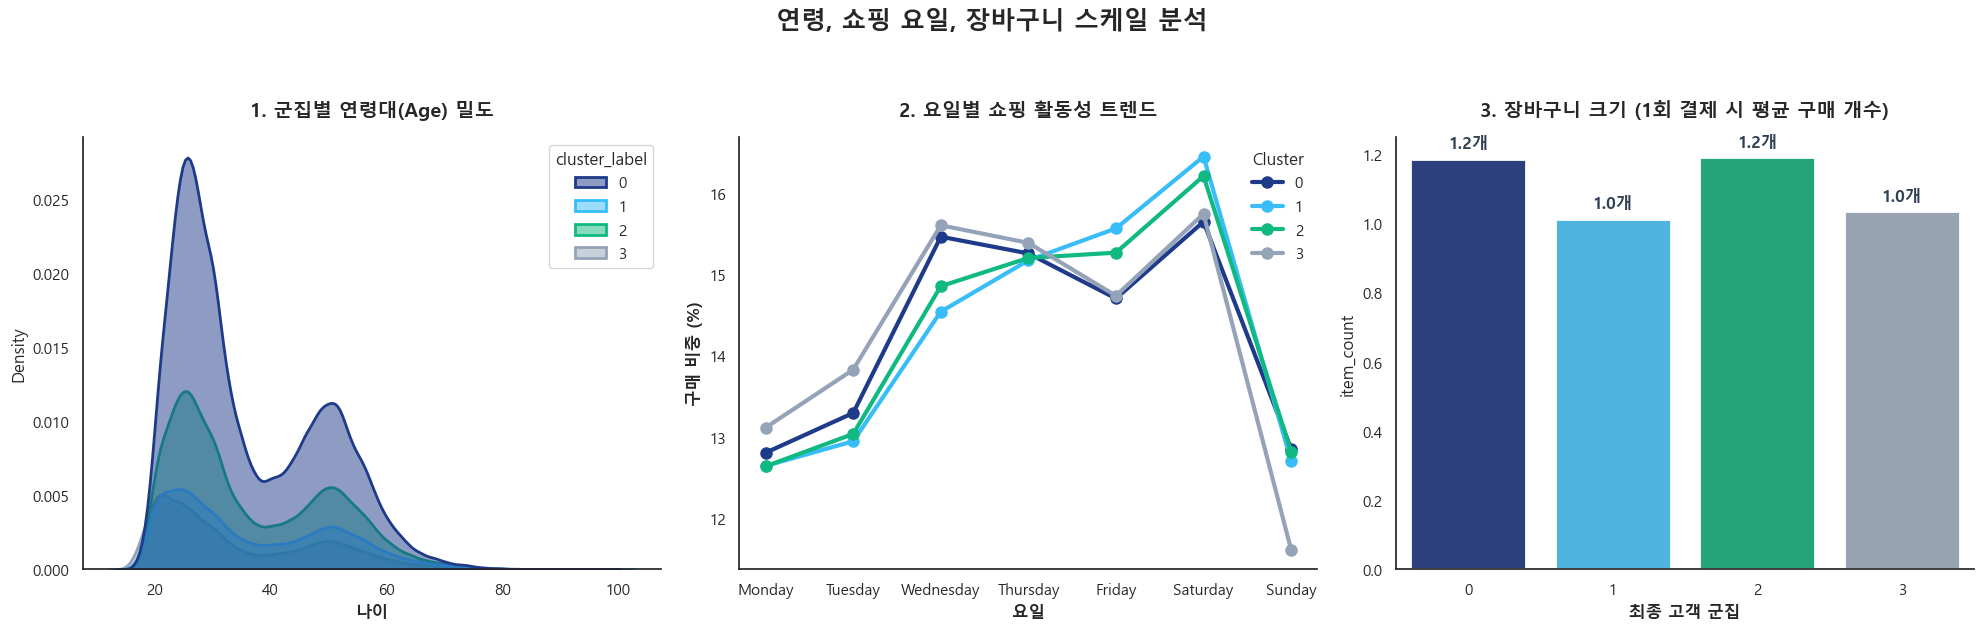

In [17]:
# 1회 주문당 평균 구매 개수 
basket_df = merged_df.groupby(['cluster_label', 't_dat', 'customer_id']).size().reset_index(name='item_count')
basket_size = basket_df.groupby('cluster_label')['item_count'].mean().reset_index()

# 요일별 구매 패턴 계산
merged_df['weekday'] = merged_df['t_dat'].dt.day_name()
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_df = pd.crosstab(merged_df['cluster_label'], merged_df['weekday'], normalize='index')[weekday_order] * 100

fig, axes = plt.subplots(1, 3, figsize=(20, 6), facecolor='white')
cluster_colors = ['#1E3A8A', '#38BDF8', '#10B981', '#94A3B8']

# [분석 1] 군집별 연령대 분포
sns.kdeplot(data=merged_df, x='age', hue='cluster_label', palette=cluster_colors, fill=True, ax=axes[0], alpha=0.5, linewidth=2)
axes[0].set_title('1. 군집별 연령대(Age) 밀도', fontweight='bold', fontsize=14, pad=15)
axes[0].set_xlabel('나이', fontweight='bold')
sns.despine(ax=axes[0])

# [분석 2] 요일별 구매 비중 (평일 vs 주말 패턴)
weekday_df.T.plot(kind='line', marker='o', linewidth=3, markersize=8, color=cluster_colors, ax=axes[1])
axes[1].set_title('2. 요일별 쇼핑 활동성 트렌드', fontweight='bold', fontsize=14, pad=15)
axes[1].set_xlabel('요일', fontweight='bold')
axes[1].set_ylabel('구매 비중 (%)', fontweight='bold')
axes[1].legend(title='Cluster', frameon=False)
sns.despine(ax=axes[1])

# [분석 3] 1회 주문당 장바구니 크기 (Basket Size)
sns.barplot(data=basket_size, x='cluster_label', y='item_count', palette=cluster_colors, ax=axes[2], edgecolor='white', linewidth=2)
axes[2].set_title('3. 장바구니 크기 (1회 결제 시 평균 구매 개수)', fontweight='bold', fontsize=14, pad=15)
axes[2].set_xlabel('최종 고객 군집', fontweight='bold')
for p in axes[2].patches:
    axes[2].annotate(f"{p.get_height():.1f}개", (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=12, fontweight='bold', color='#334155', xytext=(0, 5), textcoords='offset points')
sns.despine(ax=axes[2])

plt.suptitle("연령, 쇼핑 요일, 장바구니 스케일 분석", fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

KeyError: ['perceived_colour_master_name']

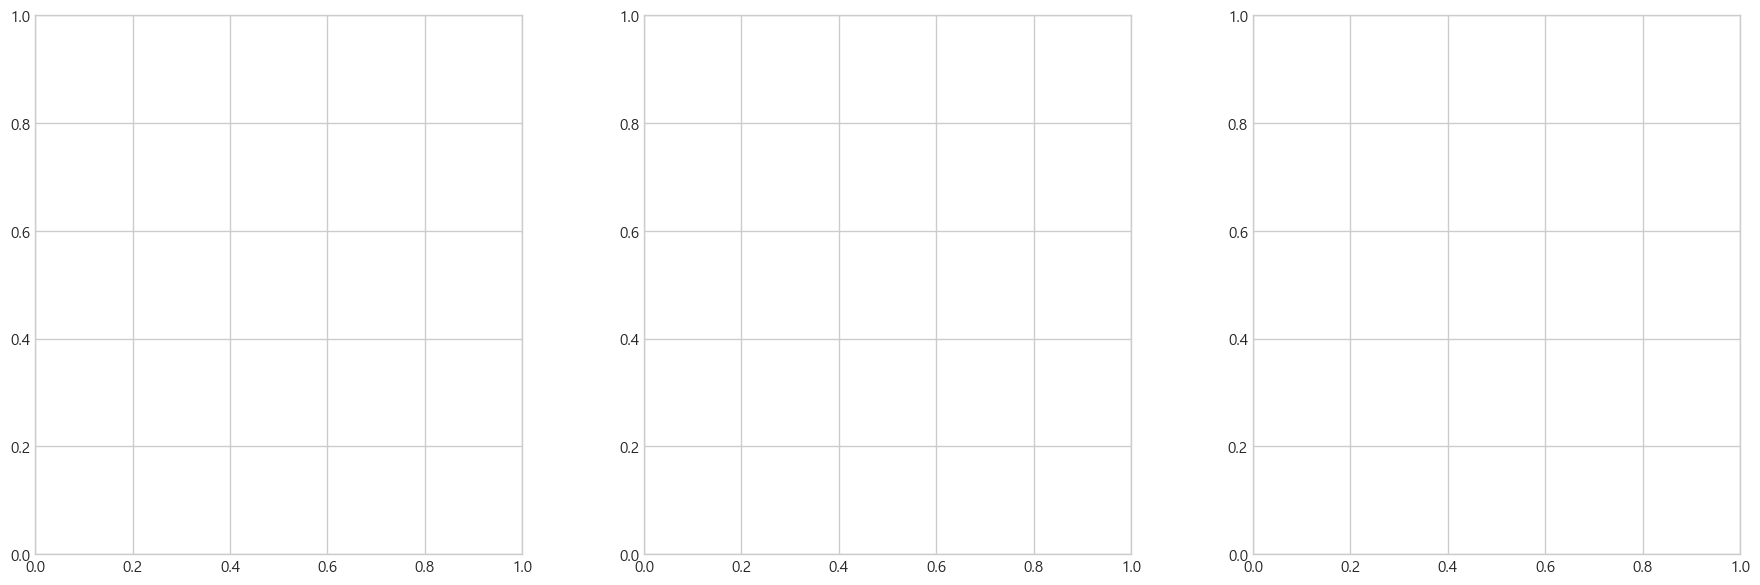

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. 폰트 및 스타일 설정
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'Malgun Gothic' # 윈도우용
plt.rcParams['axes.unicode_minus'] = False

# =====================================================================
# 팀장님 데이터 컬럼명: 'perceived_colour_master_name', 'product_group_name' 적용
# =====================================================================

# 1. 가격대(Price Tier) 구분 (저/중/고가)
q33, q66 = merged_df['price_krw'].quantile([0.33, 0.66])
merged_df['price_tier'] = pd.cut(
    merged_df['price_krw'], 
    bins=[0, q33, q66, float('inf')], 
    labels=['저가 (Low)', '중가 (Mid)', '고가 (High)']
)

# 2. 세련된 컬러 팔레트 설정
colors_price = ['#EAEAEA', '#9CA3AF', '#1A1A1A']
colors_stack = ['#1A1A1A', '#4A4A4A', '#8F8F8F', '#CCCCCC', '#E50010'] 

# 3. 레이아웃 설정
fig, axes = plt.subplots(1, 3, figsize=(22, 7), facecolor='white', gridspec_kw={'wspace': 0.25})

# ---------------------------------------------------------------------
# [분석 4] 군집별 선호 색상 (Top 5 Color)
# ---------------------------------------------------------------------
# 수정됨: perceived_colour_master_name
valid_color_df = merged_df.dropna(subset=['perceived_colour_master_name', 'cluster_label'])
top_colors = valid_color_df['perceived_colour_master_name'].value_counts().nlargest(5).index

color_df = pd.crosstab(
    valid_color_df['cluster_label'], 
    valid_color_df[valid_color_df['perceived_colour_master_name'].isin(top_colors)]['perceived_colour_master_name'], 
    normalize='index'
) * 100

color_df = color_df[top_colors] 
color_df.plot(kind='bar', stacked=True, ax=axes[0], color=colors_stack, edgecolor='white', linewidth=1.5)

axes[0].set_title('4. 핵심 고객군별 선호 색상 비중(%)', fontweight='bold', fontsize=16, pad=20)
axes[0].set_xlabel('')
axes[0].set_ylabel('비중 (%)', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=0, labelsize=11) 
axes[0].legend(title='Top 5 Colors', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
sns.despine(ax=axes[0])

# ---------------------------------------------------------------------
# [분석 5] 세부 의류 그룹 (Garment Group) 집중도
# ---------------------------------------------------------------------
# 수정됨: product_group_name
valid_garment_df = merged_df.dropna(subset=['product_group_name', 'cluster_label'])
garment_df = pd.crosstab(valid_garment_df['cluster_label'], valid_garment_df['product_group_name'], normalize='index') * 100
top_garments = garment_df.mean().nlargest(6).index

sns.heatmap(
    garment_df[top_garments].T, 
    cmap='Reds', 
    annot=True, 
    fmt='.0f', 
    annot_kws={'size': 12, 'weight': 'bold'}, 
    linewidths=2, 
    linecolor='white',
    cbar_kws={'shrink': 0.8, 'label': '비중(%)'},
    ax=axes[1]
)

axes[1].set_title('5. 세부 의류 카테고리 집중도', fontweight='bold', fontsize=16, pad=20)
axes[1].set_xlabel('')
axes[1].set_ylabel('')
axes[1].tick_params(axis='y', rotation=0, labelsize=11)
axes[1].tick_params(axis='x', rotation=0, labelsize=11)

# ---------------------------------------------------------------------
# [분석 6] 가격대별(Price Tier) 구매 비중
# ---------------------------------------------------------------------
price_tier_df = pd.crosstab(merged_df['cluster_label'], merged_df['price_tier'], normalize='index') * 100
price_tier_df.plot(kind='bar', ax=axes[2], color=colors_price, edgecolor='black', linewidth=1)

axes[2].set_title('6. 군집별 가격 수용력 (Price Tier)', fontweight='bold', fontsize=16, pad=20)
axes[2].set_xlabel('')
axes[2].set_ylabel('비중 (%)', fontsize=12, fontweight='bold')
axes[2].tick_params(axis='x', rotation=0, labelsize=11)
axes[2].legend(title='Price Tier', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
sns.despine(ax=axes[2])

# ---------------------------------------------------------------------
# 전체 마무리
# ---------------------------------------------------------------------
plt.suptitle("🎯 하이브리드 페르소나별 상품/가격 선호도 분석", fontsize=22, fontweight='heavy', y=1.05)
plt.tight_layout()
plt.show()

C:\Users\urina\AppData\Local\Temp\ipykernel_30480\2729411133.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=repurchase_rate, x='cluster_label', y='repurchase_rate', palette=cluster_colors, ax=axes[1], edgecolor='white', linewidth=2)


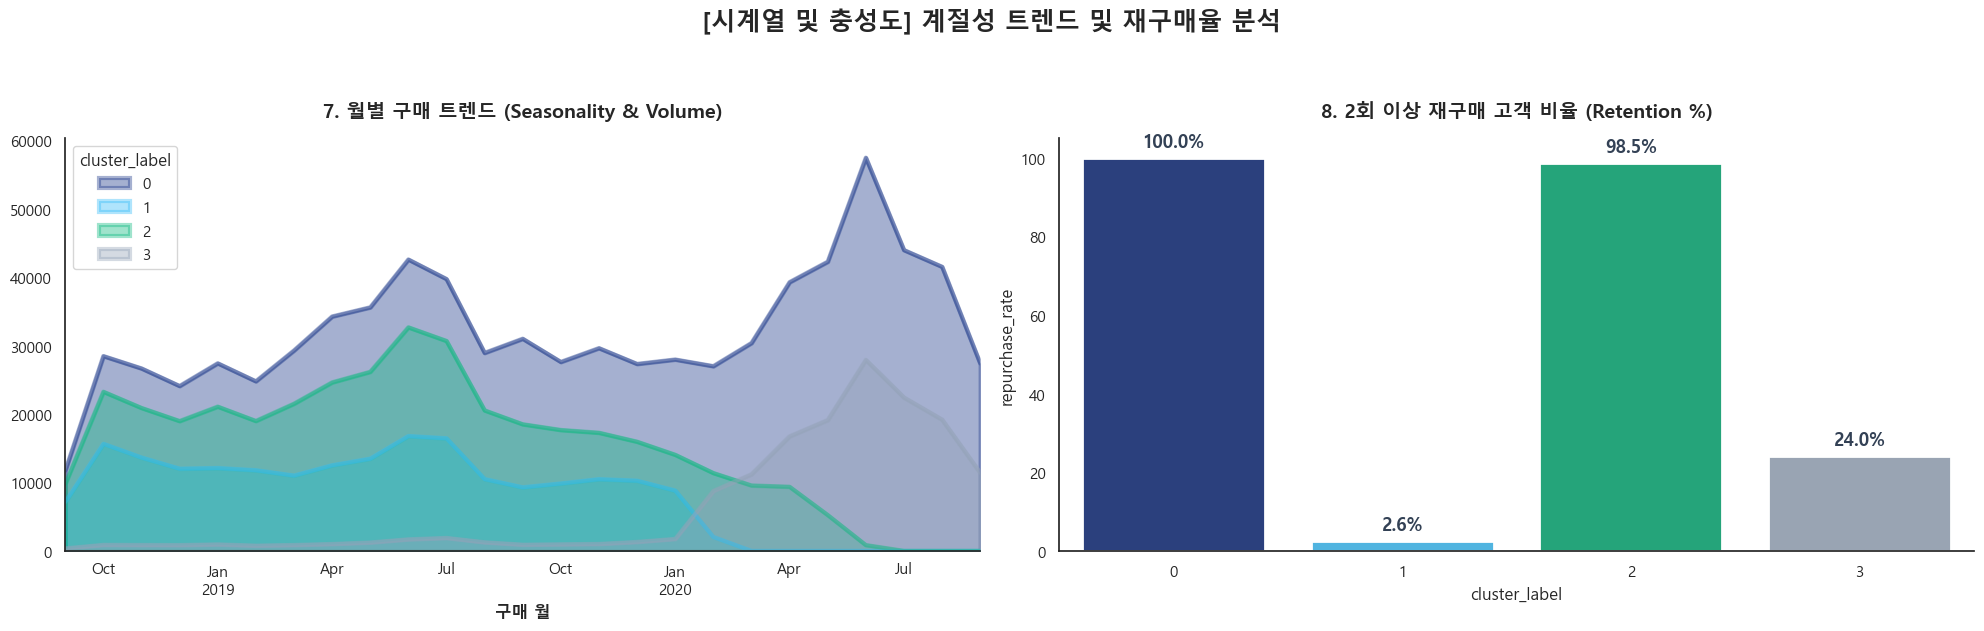


 [분석 9 & 10] 군집별 '절대 실패하지 않는' 핵심 매출 견인 상품 (Anchor Items)


,군집 (Cluster),최애 상품 ID,최애 상품명 (Anchor),해당 상품 누적 매출
0,Cluster 0,706016001,Jade HW Skinny Denim TRS,"32,455,910 원"
1,Cluster 1,706016001,Jade HW Skinny Denim TRS,"8,229,640 원"
2,Cluster 2,706016001,Jade HW Skinny Denim TRS,"15,363,000 원"
3,Cluster 3,759871002,Tilda tank,"1,483,680 원"


In [19]:
# [분석 7] 월별 매출 트렌드 (Seasonality)
merged_df['month'] = merged_df['t_dat'].dt.to_period('M')
monthly_trend = merged_df.groupby(['month', 'cluster_label']).size().unstack(fill_value=0)

# [분석 8] 재구매 고객 비율 계산 (2회 이상 구매한 고객 비중)
repurchase_df = merged_df.groupby(['cluster_label', 'customer_id']).size().reset_index(name='purchases')
repurchase_rate = repurchase_df.groupby('cluster_label').apply(lambda x: (x['purchases'] > 1).mean() * 100).reset_index(name='repurchase_rate')

fig, axes = plt.subplots(1, 2, figsize=(20, 6), facecolor='white')

# 월별 구매 볼륨 트렌드
monthly_trend.plot(kind='area', stacked=False, alpha=0.4, color=cluster_colors, ax=axes[0], linewidth=3)
axes[0].set_title('7. 월별 구매 트렌드 (Seasonality & Volume)', fontweight='bold', fontsize=14, pad=15)
axes[0].set_xlabel('구매 월', fontweight='bold')
sns.despine(ax=axes[0])

# 군집별 재구매(Retention) 비율
sns.barplot(data=repurchase_rate, x='cluster_label', y='repurchase_rate', palette=cluster_colors, ax=axes[1], edgecolor='white', linewidth=2)
axes[1].set_title('8. 2회 이상 재구매 고객 비율 (Retention %)', fontweight='bold', fontsize=14, pad=15)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=13, fontweight='bold', color='#334155', xytext=(0, 5), textcoords='offset points')
sns.despine(ax=axes[1])

plt.suptitle("[시계열 및 충성도] 계절성 트렌드 및 재구매율 분석", fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


# ==========================================
# [분석 9 & 10] 군집별 매출 1위 (Anchor) 상품 리스트 도출
# ==========================================
print("\n [분석 9 & 10] 군집별 '절대 실패하지 않는' 핵심 매출 견인 상품 (Anchor Items)")

top_items_per_cluster = []
for cluster in sorted(merged_df['cluster_label'].unique()):
    cluster_data = merged_df[merged_df['cluster_label'] == cluster]
    top_item = cluster_data['article_id'].value_counts().nlargest(1).index[0]
    top_item_name = articles[articles['article_id'] == top_item]['prod_name'].iloc[0]
    total_sales = cluster_data[cluster_data['article_id'] == top_item]['price_krw'].sum()
    
    top_items_per_cluster.append({
        '군집 (Cluster)': f"Cluster {cluster}",
        '최애 상품 ID': top_item,
        '최애 상품명 (Anchor)': top_item_name,
        '해당 상품 누적 매출': f"{int(total_sales):,} 원"
    })

top_items_df = pd.DataFrame(top_items_per_cluster)
styled_top_items = top_items_df.style.set_properties(**{'text-align': 'center', 'border': '1px solid #E5E7EB', 'padding': '10px'})\
                             .set_caption("<b style='font-size:15px; color:#1E293B;'>[군집별 최애 앵커 상품 리스트] (프로모션 미끼 상품)</b>")
display(styled_top_items)

In [ ]:
# import pandas as pd
# import numpy as np
# import os

# print("[태블로/스트림릿용] 최종 마스터 데이터셋 병합 및 정제 시작...")

# # 1. 기존 transactions, articles, customers, cluster_df 병합
# if 'style_cluster' in cluster_df.columns:
#     cluster_df = cluster_df.rename(columns={'style_cluster': 'cluster_label'})

# # 빠른 병합을 위해 inner join 수행
# final_df = transactions.merge(cluster_df, on='customer_id', how='inner')
# final_df = final_df.merge(articles[['article_id', 'prod_name', 'product_group_name', 'index_group_name', 'colour_group_name']], on='article_id', how='left')
# final_df = final_df.merge(customers[['customer_id', 'age']], on='customer_id', how='left')

# # 2. 직관적인 클러스터 이름 부여
# cluster_mapping = {
#     0: '0_VIP (온라인 프리미엄)', 
#     2: '1_우수 (오프라인 실속)',
#     1: '2_일반 (체리피커)',
#     3: '3_이탈위기 (수면 큰손)'
# }
# final_df['Cluster_Persona'] = final_df['cluster_label'].map(cluster_mapping)

# # 3. 원화(KRW) 변환 로직 
# if 'price_krw' not in final_df.columns and 'price_KRW' not in final_df.columns:
#     final_df['price_krw'] = (final_df['price'] * 590 * 1314).astype(int)
#     final_df['price_krw'] = (final_df['price_krw'] // 10) * 10
# elif 'price_KRW' in final_df.columns:
#     final_df = final_df.rename(columns={'price_KRW': 'price_krw'})

# # 4. 날짜 데이터 타입 세팅 (★ 에러 해결 핵심: 억지로 문자열로 바꾸지 않고 순수 Datetime 유지)
# final_df['t_dat'] = pd.to_datetime(final_df['t_dat'])

# # 5. 대시보드에 꼭 필요한 핵심 컬럼만 추출
# cols_to_keep = [
#     't_dat', 'customer_id', 'article_id', 'price_krw', 'sales_channel_id', 
#     'cluster_label', 'Cluster_Persona', 
#     'age',                              
#     'prod_name', 'product_group_name', 'index_group_name', 'colour_group_name'
# ]
# final_dashboard_data = final_df[cols_to_keep]

# # 6. 파일로 저장 
# # csv_filename = "Final_Dashboard_Master.csv"
# # parquet_filename = "Final_Dashboard_Master.parquet"
# # final_dashboard_data.to_csv(csv_filename, index=False, encoding='utf-8-sig') 

# # ★ 에러 해결 핵심: 충돌을 일으키는 fastparquet 대신 가장 안정적인 기본 엔진(auto/pyarrow) 사용
# # final_dashboard_data.to_parquet(parquet_filename, engine='auto')

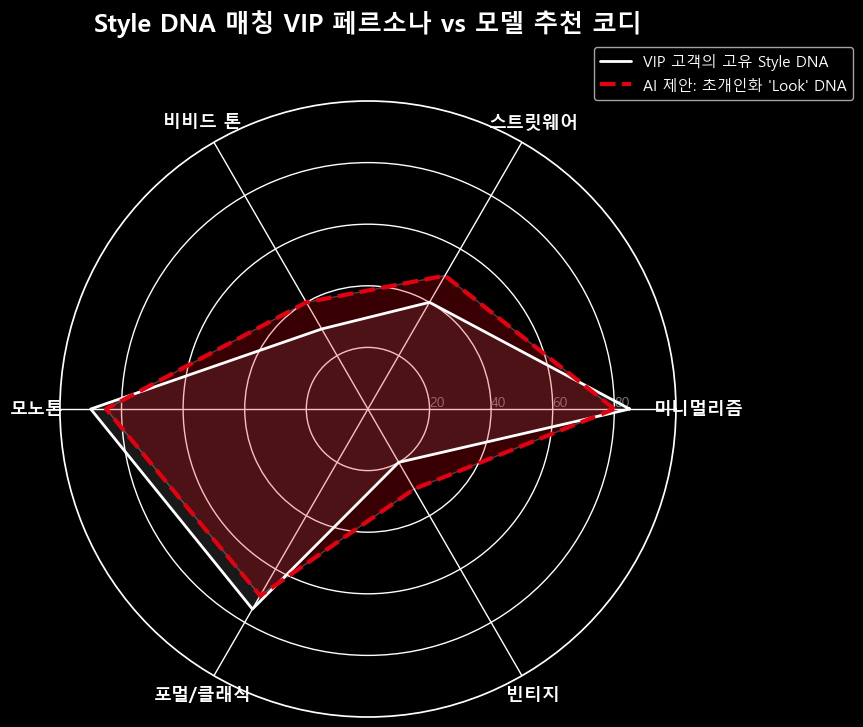

In [ ]:
# 세련된 다크 테마 설정 (발표장 화면에서 압도적인 임팩트)
plt.style.use('dark_background')
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, polar=True)

# CLIP 기반으로 추출해낸 '스타일 DNA' 차원 (예시)
categories = ['미니멀리즘', '스트릿웨어', '비비드 톤', '모노톤', '포멀/클래식', '빈티지']
N = len(categories)

# 각도 설정
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

# 1. 특정 VIP 고객의 과거 구매 기반 'Style DNA' (하얀색 실선)
user_dna = [85, 40, 30, 90, 75, 20] 
user_dna += user_dna[:1]

# 2. GNN이 새롭게 추천하는 '크로스셀링 코디(자켓+팬츠)'의 Style DNA (빨간색 점선)
ai_dna = [80, 50, 40, 85, 70, 30] 
ai_dna += ai_dna[:1]

# 고객 DNA 그리기
ax.plot(angles, user_dna, linewidth=2, linestyle='solid', label="VIP 고객의 고유 Style DNA", color='#FFFFFF')
ax.fill(angles, user_dna, '#FFFFFF', alpha=0.1)

# AI 추천 코디 DNA 그리기 (H&M의 시그니처 레드 컬러 활용)
ax.plot(angles, ai_dna, linewidth=3, linestyle='--', label="모델 제안: 초개인화 'Look' DNA", color='#E50010')
ax.fill(angles, ai_dna, '#E50010', alpha=0.25)

# 축 및 라벨 포맷팅
plt.xticks(angles[:-1], categories, color='white', size=13, fontweight='bold')
ax.set_rlabel_position(0)
plt.yticks([20, 40, 60, 80], ["20", "40", "60", "80"], color="grey", size=10)
plt.ylim(0, 100)

plt.title("Style 매칭 VIP 페르소나 vs 모델 추천 코디", size=18, color='white', y=1.1, fontweight='bold')
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.show()
# plt.savefig('style_dna_radar.png', dpi=300, transparent=True) # PPT 삽입용 저장

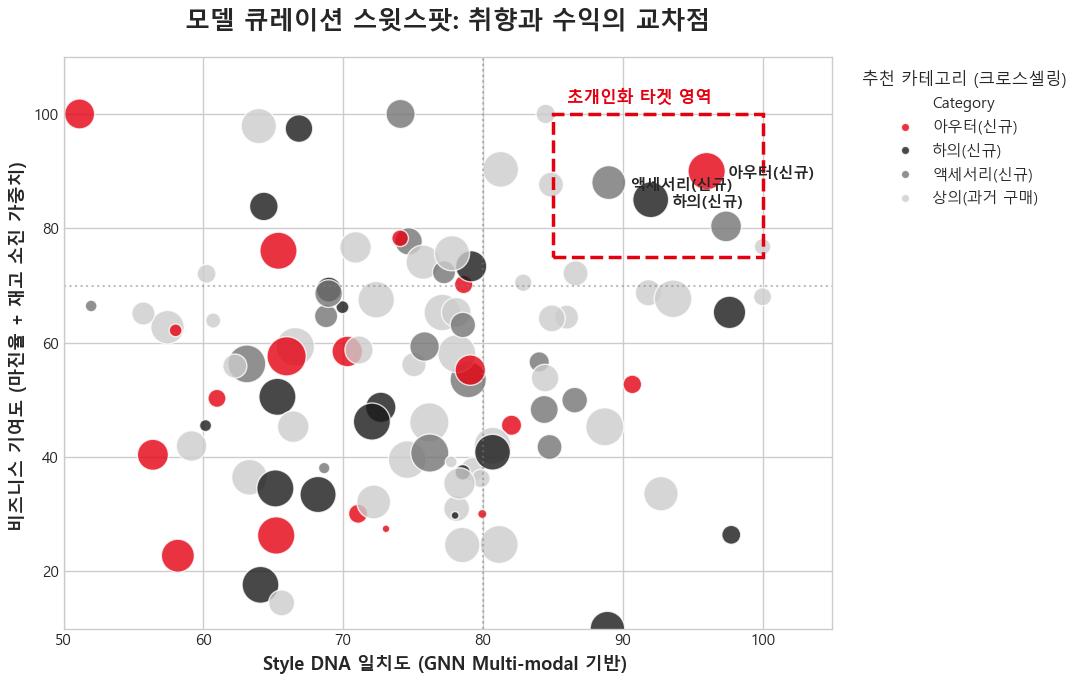

In [26]:
# 깔끔하고 모던한 컨설팅 펌 스타일 (White Theme)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'Malgun Gothic' # 윈도우용 (맥은 AppleGothic)
plt.rcParams['axes.unicode_minus'] = False

# [시뮬레이션 데이터 생성] 실제 모델 결과물의 분포를 모방
np.random.seed(42)
n_items = 100
df = pd.DataFrame({
    'Category': np.random.choice(['상의(과거 구매)', '아우터(신규)', '하의(신규)', '액세서리(신규)'], n_items, p=[0.4, 0.2, 0.2, 0.2]),
    'Style_Match_Score': np.random.normal(75, 12, n_items).clip(0, 100), 
    'Profit_Margin_Index': np.random.normal(55, 20, n_items).clip(10, 100), 
    # 해결책: int 대신 float로 타입 강제 변환하여 할당 오류 방지
    'Inventory_Level': np.random.randint(50, 500, n_items).astype(float) 
})

# 우상단(Sweet Spot)에 초개인화 '코디 세트' 강제 매핑 
sweet_spot = [0, 1, 2]
df.loc[sweet_spot, 'Style_Match_Score'] = [96.0, 92.0, 89.0]
df.loc[sweet_spot, 'Profit_Margin_Index'] = [90.0, 85.0, 88.0]
df.loc[sweet_spot, 'Category'] = ['아우터(신규)', '하의(신규)', '액세서리(신규)']
df.loc[sweet_spot, 'Inventory_Level'] = [450.0, 420.0, 380.0] 

fig, ax = plt.subplots(figsize=(11, 7))
colors = {'상의(과거 구매)': '#CCCCCC', '아우터(신규)': '#E50010', '하의(신규)': '#1A1A1A', '액세서리(신규)': '#757575'}

# 버블 차트 그리기
scatter = sns.scatterplot(
    data=df, x='Style_Match_Score', y='Profit_Margin_Index',
    hue='Category', size='Inventory_Level', sizes=(30, 800), alpha=0.8,
    palette=colors, edgecolor='white', linewidth=1, ax=ax
)

# [핵심] Sweet Spot 강조 박스
rect = Rectangle((85, 75), 15, 25, fill=False, color='#E50010', linestyle='--', linewidth=2.5)
ax.add_patch(rect)
ax.text(86, 102, "초개인화 타겟 영역", 
        color='#E50010', fontsize=12, fontweight='bold')

# Sweet Spot 상품 라벨링
for i in sweet_spot:
    ax.annotate(df.loc[i, 'Category'], 
                (df.loc[i, 'Style_Match_Score'], df.loc[i, 'Profit_Margin_Index']),
                xytext=(15, -5), textcoords='offset points', fontsize=11, fontweight='bold')

# 축 및 포맷팅
ax.set_title("모델 큐레이션 스윗스팟: 취향과 수익의 교차점", fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel("Style DNA 일치도 (GNN Multi-modal 기반) ", fontsize=13, fontweight='bold')
ax.set_ylabel("비즈니스 기여도 (마진율 + 재고 소진 가중치) ", fontsize=13, fontweight='bold')
ax.set_xlim(50, 105)
ax.set_ylim(10, 110)

ax.axvline(x=80, color='grey', linestyle=':', alpha=0.5)
ax.axhline(y=70, color='grey', linestyle=':', alpha=0.5)

# 범례 정리
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles[:5], labels=labels[:5], title="추천 카테고리 (크로스셀링)", bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()